<a href="https://colab.research.google.com/github/ChaithraKNagaraju/ecg-classification/blob/master/Arrhythmia_Classification_Full_and_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Single-Lead ECG Arrhythmia Classification**


---

By- Md Rabiul Islam



## **a. Summary, At a Glance**


*   **Task:** Arrhythmia Classification, 5 classes
*   **Dataset:** MIT-BIH ECG dataset, Dataset website: [Here](https://physionet.org/content/mitdb/1.0.0/)
*   **Model:** CNN_LSTM with Attention
*   **Made By:** Md Rabiul Islam, PhD Student, Texas A&M University. [Personal Website](https://sites.google.com/view/rabiuleeekuet/home). [Google Scholar](https://scholar.google.com/citations?user=GfveUqIAAAAJ&hl=en). Email: rabiul.kuet.bd@gmail.com.
*   **Supervised By:** Prof. Dr. Erchin Serpedin. (Collaboration: Prof. Dr. Khalid Qaraqe, Assoc. Prof. Dr. Marwa Qaraqe)
*   **Date:** November 2022 - January 2023

## **b. Information about Dataset:**


The dataset can be downloaded from the original [website](https://physionet.org/content/mitdb/1.0.0/) or by clicking the [link](https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip) directly. The overall information about the dataset is given [here](https://archive.physionet.org/physiobank/database/html/mitdbdir/intro.htm).
1. The MIT-BIH dataset contains **48 readings**.
2. Number of **patients = 47** (25 Men, 22 Women). Only 1 patient has 2 readings. Rest 1 readings/patients.
3. Each reading contains a. ECG signals b. Annotations
4. ECG signals length = **30 Minutes** (or slightly over). Sampling Frequency = **360 Hz**.
5. Each reading contains **2 Lead ECG** signals that are Modified Limb Lead II and Modified Lead V1 (Occationally V2, V5, V4 just only once). Simply, Two Leads: **MLII, V1**.
6. Annotation is given for each beat. Although 20 types of beats are annotated in dataset. We consider only **15 types** of beats grouped in **5 classes** followed by the recommendation of **AAMI**.
* N - Normal
* S - Supraventricular premature beat
* V - Premature ventricular contraction
* F - Fusion of ventricular and normal beat
* Q - Unclassifiable / Unknown beat

### **Additional Dataset Information:**
The source of the ECGs included in the MIT-BIH Arrhythmia Database is a set of over **4000 long-term Holter recordings** that were obtained by the **Beth Israel Hospital** Arrhythmia Laboratory between **1975 and 1979**. Approximately **60%** of these recordings were obtained from **inpatients**. The subjects were 25 men aged 32 to 89 years, and 22 women aged 23 to 89 years

# **Main Parts of the Study:**

1.   **Part A: Installing Packages and Basic Visualization of ECG**
2.   **Part B: Denoising, R-Peak Detection, Segmentation**
3.   **Part C: Dataset Loading**
4.   **Part D: Train-Test Splitting and Class Balancing**
5.   **Part E: Model Building and Training**
6.   **Part F: Results**

# **Part A: Installing Packages and Basic Visualization of ECG**

## **A1: Installing Packages**

In [7]:
# wfdb is not normally installed in Colab
!pip install wfdb

In [8]:
# Importing packages
import os
import datetime
import wfdb
import pywt
import seaborn
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from os.path import join as osj
import pandas as pd

## **A2: Basic Visualization of ECG**
Basic code for loading (reading), plotting and playing with ECG signals

### **a. Getting Recordings' IDs**
The ECG recordings are named after Patients' IDs (from 100 to 234), sorted but not consecutive. Total 48 recordings.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
!ls "/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"

 100.atr     111.xws   123.hea	 212.atr   228.hea
 100.dat     112.atr   123.xws	 212.dat   228.xws
 100.hea     112.dat   124.atr	 212.hea   230.atr
 100.xws     112.hea   124.dat	 212.xws   230.dat
 101.atr     112.xws   124.hea	 213.atr   230.hea
 101.dat     113.atr   124.xws	 213.dat   230.xws
 101.hea     113.dat   200.atr	 213.hea   231.atr
 101.xws     113.hea   200.dat	 213.xws   231.dat
 102-0.atr   113.xws   200.hea	 214.at_   231.hea
 102.atr     114.atr   200.xws	 214.atr   231.xws
 102.dat     114.dat   201.atr	 214.dat   232.atr
 102.hea     114.hea   201.dat	 214.hea   232.dat
 102.xws     114.xws   201.hea	 214.xws   232.hea
 103.atr     115.atr   201.xws	 215.at_   232.xws
 103.dat     115.dat   202.atr	 215.atr   233.atr
 103.hea     115.hea   202.dat	 215.dat   233.dat
 103.xws     115.xws   202.hea	 215.hea   233.hea
 104.atr     116.atr   202.xws	 215.xws   233.xws
 104.dat     116.dat   203.at-	 217.atr   234.atr
 104.hea     116.hea   203.at_	 217.dat   234.dat


In [11]:
!find /content -type f -name "code_17_t5_weights.hdf5"

In [12]:
import pandas as pd
import numpy as np
# Path to dataset folder
DATA_ROOT = "/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0"
# Path to RECORDS file
record_file = f"{DATA_ROOT}/RECORDS"
# Load record IDs
patient_ids = pd.read_csv(record_file, header=None)[0].astype(int).to_numpy()
print(patient_ids)

[100 101 102 103 104 105 106 107 108 109 111 112 113 114 115 116 117 118
 119 121 122 123 124 200 201 202 203 205 207 208 209 210 212 213 214 215
 217 219 220 221 222 223 228 230 231 232 233 234]


### **b. 1 Patient ECG loading and plotting**
Extracting 2 leads ECG signals of a patient (for example: 100), and saving in two lists.

In [13]:
#Extracting just 1 patient ECG signal and info
lead0 = {}  # without this it shows lead0[100] is not defined
lead1 = {}
patient_id = 100
signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(100)))
lead0[100] = signals[:, 0]
lead1[100] = signals[:, 1]

<class 'numpy.ndarray'>
(650000,)
{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal']}


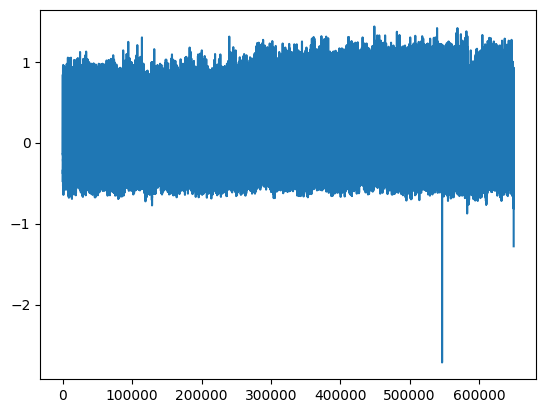

In [14]:
# Visualization of 1 patients signal and info
print(type(lead0[100]))
print(lead0[100].shape)
plt.plot(lead0[100])
print(info)

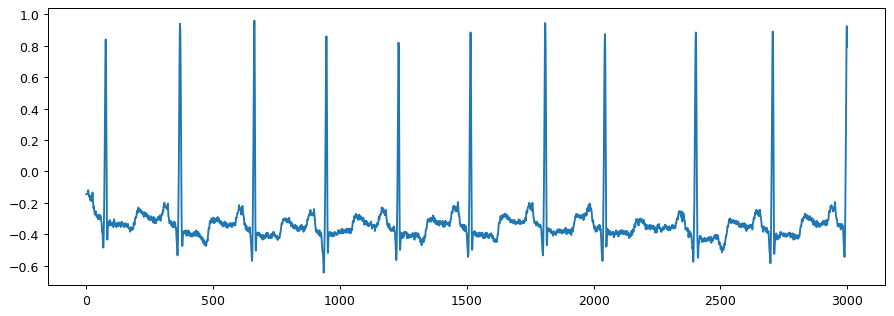

In [15]:
# ECG signal per second
a = lead0[100][0: 3000]
plt.figure(figsize=(12, 4), dpi=90)
plt.plot(a)

### **c. All patients' ECG loading**

In [16]:
# Loading all patients ECG SIGNALs using for loop
def get_ecg_signals(patient_ids):
    lead0 = {}
    lead1 = {}
    for id_ in patient_ids:
        signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(id_)))
        lead0[id_] = signals[:, 0]
        lead1[id_] = signals[:, 1]
        print(f'Signal of patient {id_} extracted')
    return lead0, lead1

In [17]:
# Loading all patient ECG INFORMATION
def get_ecg_info(patient_ids):
    _, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(patient_ids)))
    resolution = 2**11  # Number of possible signal values we can have.
    info["resolution"] = 2**11
    return info

In [18]:
lead0, lead1 = get_ecg_signals(patient_ids)

Signal of patient 100 extracted
Signal of patient 101 extracted
Signal of patient 102 extracted
Signal of patient 103 extracted
Signal of patient 104 extracted
Signal of patient 105 extracted
Signal of patient 106 extracted
Signal of patient 107 extracted
Signal of patient 108 extracted
Signal of patient 109 extracted
Signal of patient 111 extracted
Signal of patient 112 extracted
Signal of patient 113 extracted
Signal of patient 114 extracted
Signal of patient 115 extracted
Signal of patient 116 extracted
Signal of patient 117 extracted
Signal of patient 118 extracted
Signal of patient 119 extracted
Signal of patient 121 extracted
Signal of patient 122 extracted
Signal of patient 123 extracted
Signal of patient 124 extracted
Signal of patient 200 extracted
Signal of patient 201 extracted
Signal of patient 202 extracted
Signal of patient 203 extracted
Signal of patient 205 extracted
Signal of patient 207 extracted
Signal of patient 208 extracted
Signal of patient 209 extracted
Signal o

Text(0, 0.5, 'Amplitude (mV)')

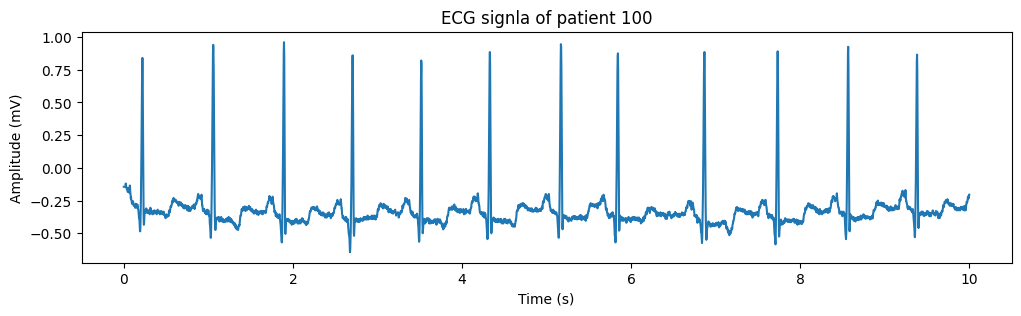

In [19]:
# Plot any patient signal from any time frame
patient_id = 100 # can change
starting_time = 0 # can change
ending_time = 10 # can change

# Scaling
starting_signal_point = starting_time*350
ending_signal_point = ending_time*350 # As sampling frequency is 350 Hz
x = np.arange(starting_time, ending_time, 1/350)
signal = lead0[patient_id][starting_signal_point: ending_signal_point]

plt.figure(figsize=(12, 3), dpi=100)
plt.plot(x, signal)
plt.title(f'ECG signla of patient {patient_id}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')

In [20]:
# ECG info of any patient
ecg_info = get_ecg_info(patient_ids[0])
ecg_info

{'fs': 360,
 'sig_len': 650000,
 'n_sig': 2,
 'base_date': None,
 'base_time': None,
 'units': ['mV', 'mV'],
 'sig_name': ['MLII', 'V5'],
 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'],
 'resolution': 2048}

# **Part B: Denoising, R-Peak Detection, Segmentation**

### **B1: Denoising**
Noise removing by using Discrete Wavelet Transform (DCT)

In [28]:
import numpy as np
import pywt

def denoise(signal):
    """
    Denoises a 1D signal (e.g., ECG) using Discrete Wavelet Transform ('db6').
    Applies soft thresholding to detail coefficients, then reconstructs the signal.
    """
    # Decompose the signal with DWT up to 4 levels using Daubechies 6
    coeffs = pywt.wavedec(signal, 'db6', level=4)

    # Estimate threshold using the detail coefficients at the highest level
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))

    # Soft threshold all detail coefficients (not the approximation)
    coeffs[1:] = [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:]]

    # Reconstruct the signal
    denoised_signal = pywt.waverec(coeffs, 'db6')

    # Ensure output length matches input (if a slight mismatch occurs)
    if len(denoised_signal) > len(signal):
        denoised_signal = denoised_signal[:len(signal)]
    elif len(denoised_signal) < len(signal):
        denoised_signal = np.pad(denoised_signal, (0, len(signal) - len(denoised_signal)), 'edge')

    return denoised_signal

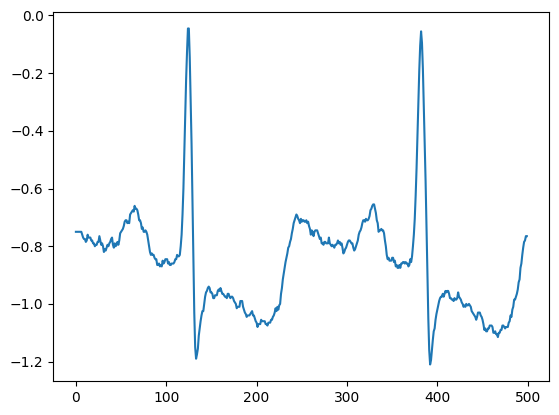

In [29]:
# Ploting a signal before denoising
project_path = r"/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"
record = wfdb.rdrecord(project_path + '112', channel_names=['MLII'])
data = record.p_signal.flatten()
plt.plot(data[0:500])

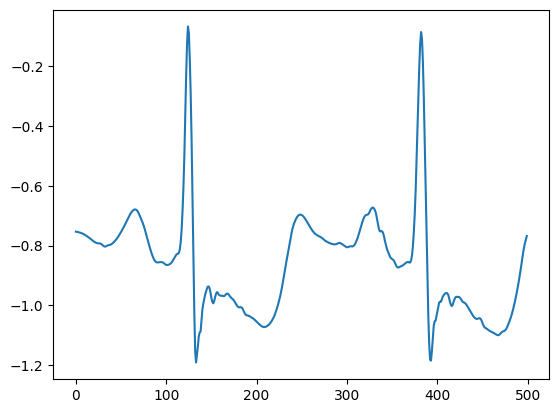

In [32]:
# Same signal after denoising
rdata = denoise(data)
plt.plot(rdata[0:500])

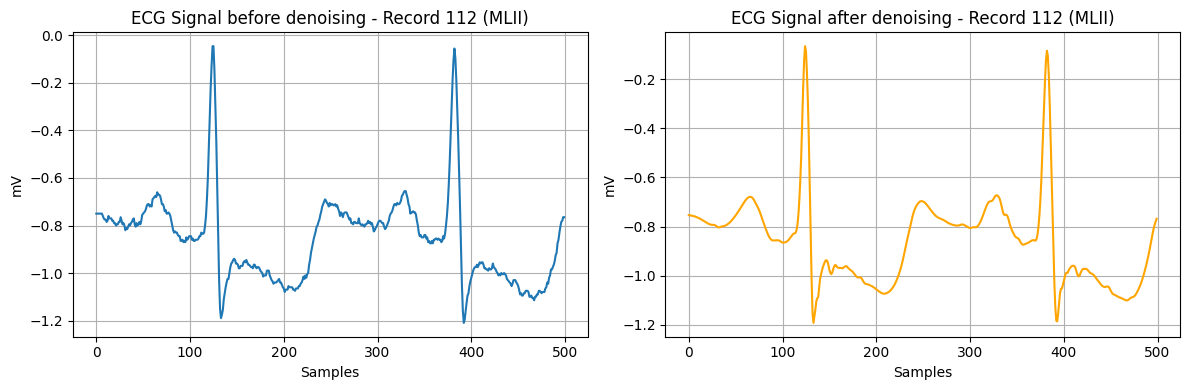

In [33]:
record_id = 112
plt.figure(figsize=(12, 4))
# Before
plt.subplot(1, 2, 1)
plt.plot(data[0:500])
plt.title(f"ECG Signal before denoising - Record {record_id} (MLII)")
plt.xlabel("Samples")
plt.ylabel("mV")
plt.grid(True)
# After
plt.subplot(1, 2, 2)
plt.plot(rdata[0:500], color="orange")
plt.title(f"ECG Signal after denoising - Record {record_id} (MLII)")
plt.xlabel("Samples")
plt.ylabel("mV")
plt.grid(True)
plt.tight_layout()
plt.show()

### **B2: R-Peak Detection**
R-peak is annotated in MIT-BIH dataset. Just need to read the file.

In [34]:
# For exmaple, we extract '100' recording annotation
annotation = wfdb.rdann(project_path + '100', 'atr')
Rlocation = annotation.sample
print(Rlocation)
Rclass = annotation.symbol
print(Rclass)

[    18     77    370 ... 649484 649734 649991]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', '

In [35]:
len(annotation.symbol)

2274

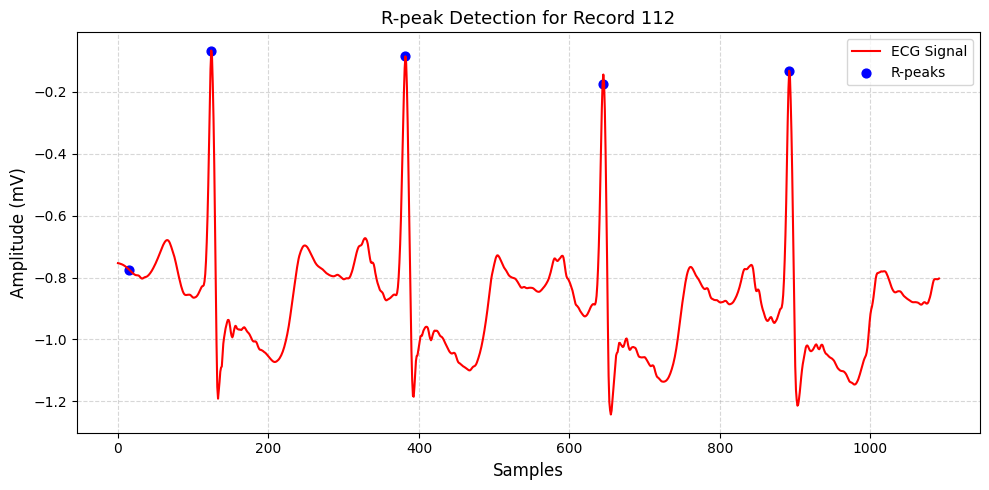

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb
# Example record (you can change this)
record = '112'
project_path = r"/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"
# Load ECG data and annotation
record_data = wfdb.rdrecord(project_path + record)
annotation = wfdb.rdann(project_path + record, 'atr')
# Extract signal and annotation info
rdata = denoise(data)                   # ECG signal (first channel)
Rlocation = annotation.sample           # R-peak sample indices
# Number of R-peaks to show (e.g., first 5)
n_peak = 5
r_peak_x = Rlocation[:n_peak]
r_peak_y = rdata[Rlocation[:n_peak]]
# Select a segment for plotting (zoomed around first few peaks)
start = Rlocation[0] - 100 if Rlocation[0] > 100 else 0
end = Rlocation[n_peak - 1] + 200
x = np.arange(start, end)
segment = rdata[start:end]
# Plot ECG with R-peaks
plt.figure(figsize=(10, 5))
plt.plot(x, segment, color='red', linewidth=1.5, label='ECG Signal')
plt.scatter(r_peak_x, r_peak_y, color='blue', s=40, label='R-peaks')
plt.title(f"R-peak Detection for Record {record}", fontsize=13)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Amplitude (mV)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **B3: Segmentation**
Each ECG signal is segmented by using a window **length of 300**. From R-peak location, **99** samples taken from **left** and **201** samples from **right**. Thus a complete **heartbeat** is found.

### **B4: Complete Preprocessing Figures**
The complete preprocessing including denosinsing, R-peak location detection and segmentation is expected to view in a single figure.

In [38]:
r_peak_xx = Rlocation[0], Rlocation[1], Rlocation[2], Rlocation[3]
r_peak_yy = rdata[Rlocation[0]], rdata[Rlocation[1]], rdata[Rlocation[2]], rdata[Rlocation[3]]

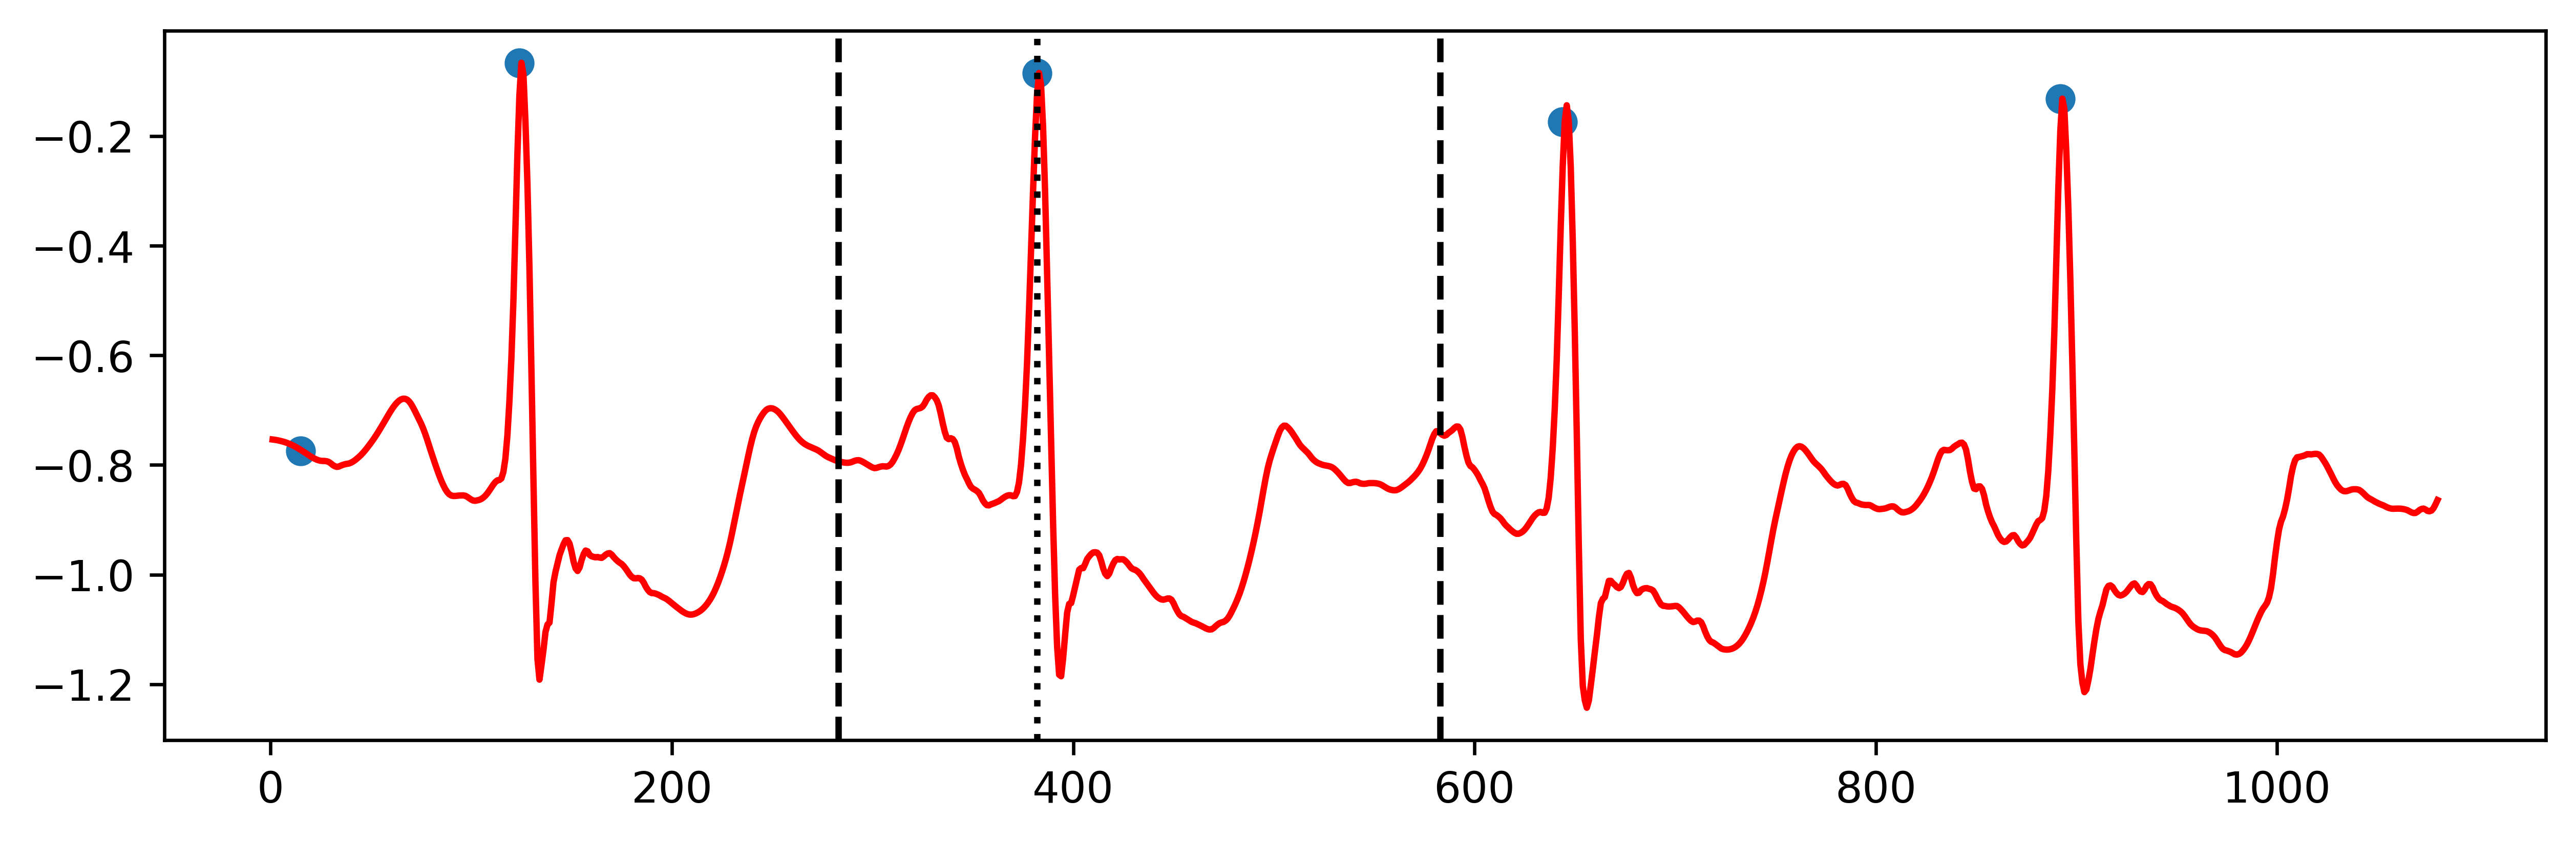

In [39]:
# Plotting R-peaks and segmentation lines
fig = plt.figure(figsize=(10,3), dpi=600)
n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])
x = np.arange(1, 1081)
plt.plot(x, rdata[0: 1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

# line plotting
plt.axvline(x = Rlocation[2], color = 'k', linestyle = ':')
plt.axvline(x = Rlocation[2]-99, color = 'k', linestyle = '--')
plt.axvline(x = Rlocation[2]+201, color = 'k', linestyle = '--')

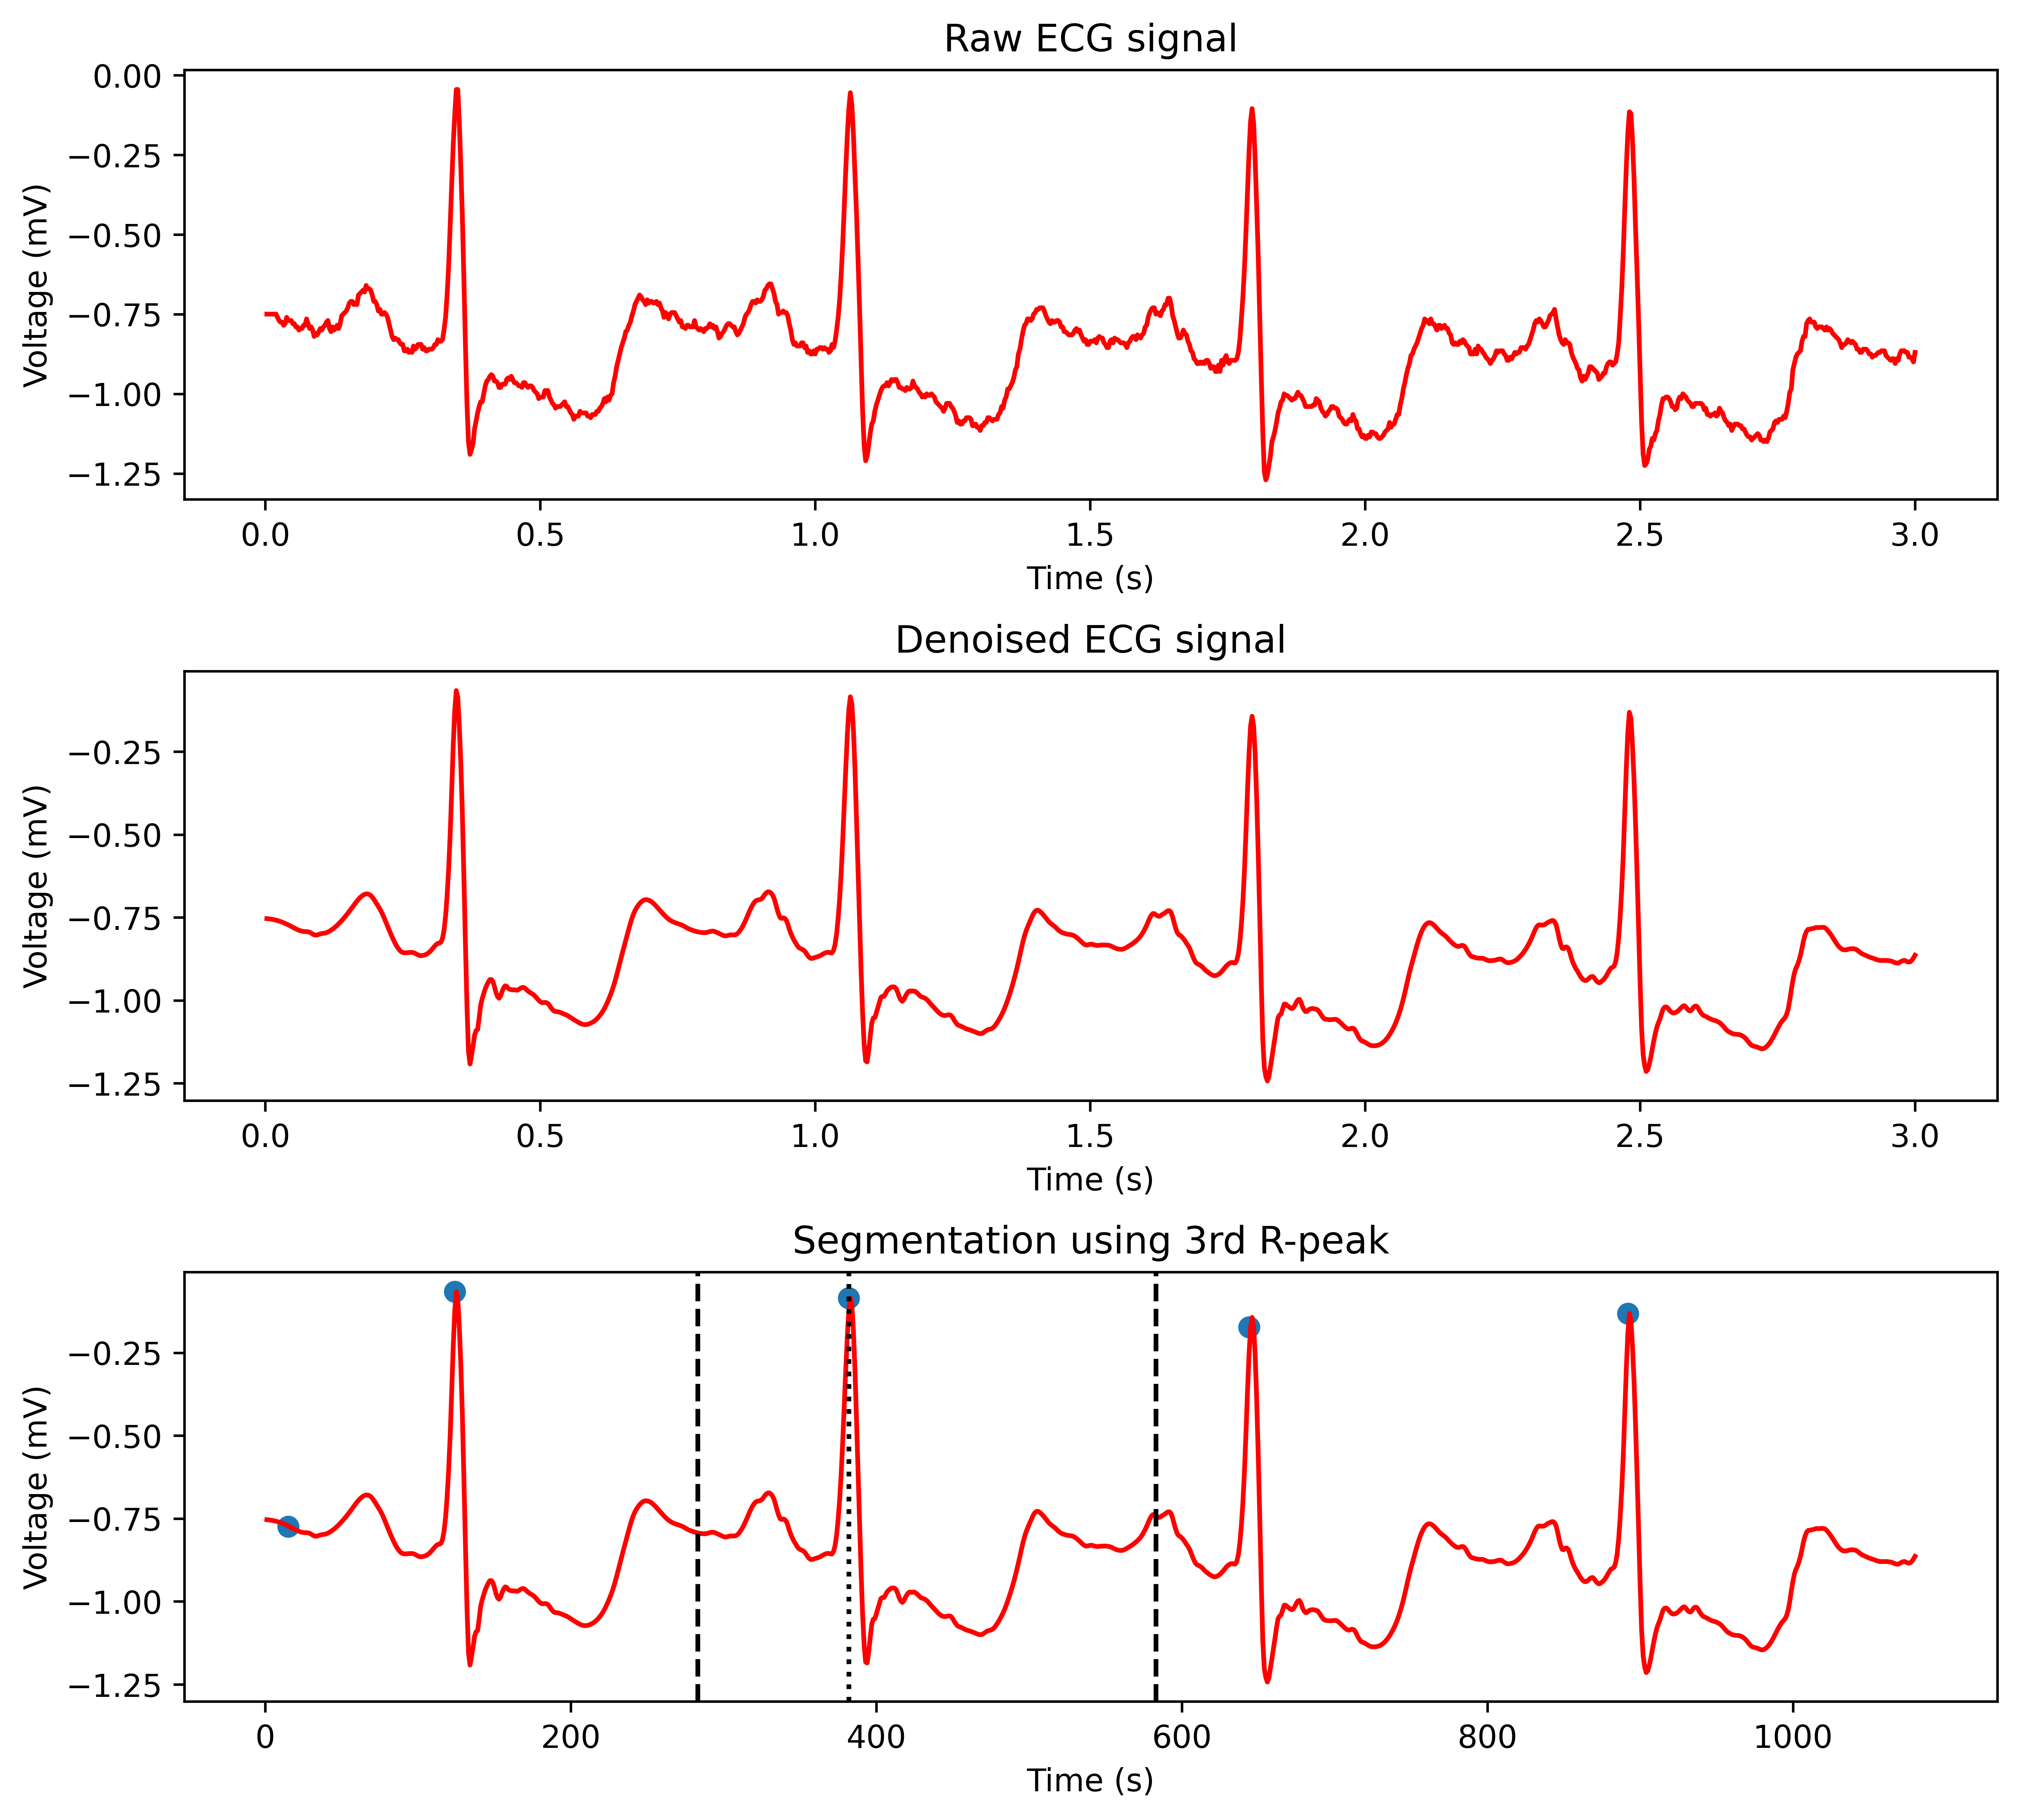

In [40]:
# Plot together raw, denoised and segmted signal
fig = plt.figure(figsize=(10,9), dpi=600)
x = np.arange(1, 1081)

# Raw signal plotting
plt.subplot(3, 1, 1)
plt.plot(x/360, data[0:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Raw ECG signal')

# Denoised signal plotting
plt.subplot(3, 1, 2)
plt.plot(x/360, rdata[0:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Denoised ECG signal')

# Segmentation visualization using two border lines
plt.subplot(3, 1, 3)
n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])
x = np.arange(1, 1081)
plt.plot(x, rdata[0: 1080], color='red')
plt.scatter(r_peak_x, r_peak_y)
# line plotting
plt.axvline(x = Rlocation[2], color = 'k', linestyle = ':') # 3rd r-peak
plt.axvline(x = Rlocation[2]-99, color = 'k', linestyle = '--')
plt.axvline(x = Rlocation[2]+201, color = 'k', linestyle = '--')

plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Segmentation using 3rd R-peak')

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)

#figure_path = '/content/gdrive/MyDrive/ECG Arrhythmia trying/Heartbeat_Figures/'
#fig.savefig(figure_path+ 'Denoised and segmented ECG.png')

# **Part C: Dataset Loading**

## **C1: Loading whole data**

In [45]:
# Read ECG signals and corresponding label
def getDataSet(number, X_data, Y_data):

    # Considering 15 types ECG heartbeats that are later grouped in 5 classes
    ecgClassSet = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q']

    # Reading Channel names
    _, info = wfdb.io.rdsamp(osj(project_path, number))
    channels = info['sig_name']
    channel1, channel2 = channels[0], channels[1]
    print(channel1, channel2)


    # Read ECG data records
    print("reading " + number+ " ECG data...")
    record = wfdb.rdrecord(project_path + number, channel_names=[channel1])
    data = record.p_signal.flatten()
    rdata = denoise(data)

    # Obtain the position and corresponding label of the R wave in the ECG data record
    annotation = wfdb.rdann(project_path + number, 'atr')
    Rlocation = annotation.sample
    Rclass = annotation.symbol

    # Unstable data before and after removal
    start = 2  # if it creates problem then except will do the job
    end = 3
    i = start
    j = len(annotation.symbol) - end

    # Making labels, Y_data Convert NSVFQ in order to 0123456...14
    while i < j:
        try:
            beat_type = Rclass[i]
            lable = ecgClassSet.index(beat_type)  # when beat is like '+' or other it will go on except loop
            x_train = rdata[Rlocation[i] - 99:Rlocation[i] + 201]
            X_data.append(x_train)
            Y_data.append(lable)
            i += 1
        except ValueError:
            # print(f' when i = {i}, beat type is out of our choise. For example +, [, ! or other')
            i += 1
    return X_data, Y_data

In [46]:
# Load the dataset and preprocess it
def loadData():
    numberSet = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                 '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
                 '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
                 '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
                 '222', '223', '228', '230', '231', '232', '233', '234'] # 48 readings
    dataSet = []
    lableSet = []
    for n in numberSet:
        # getDataSet(n, dataSet, lableSet)
        dataSet, lableSet = getDataSet(n, dataSet, lableSet)

    # Turn numpy array, scramble the order
    dataSet = np.array(dataSet).reshape(-1, 300)
    lableSet = np.array(lableSet).reshape(-1, 1)
    train_ds = np.hstack((dataSet, lableSet))
    np.random.shuffle(train_ds)

    # dataset and its label set
    X = train_ds[:, :300]
    Y = train_ds[:, 300]
    return X, Y

In [47]:
# Input X and Output Y data loading
X, Y = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

In [48]:
from collections import Counter
# Assuming Y is your list/array of heartbeat classes
Y_list = list(Y)
count_dict = Counter(Y_list)
print(count_dict)

Counter({np.float64(0.0): 74920, np.float64(1.0): 8063, np.float64(2.0): 7244, np.float64(9.0): 7123, np.float64(12.0): 7012, np.float64(5.0): 2540, np.float64(13.0): 982, np.float64(11.0): 802, np.float64(4.0): 229, np.float64(6.0): 150, np.float64(10.0): 106, np.float64(7.0): 83, np.float64(14.0): 33, np.float64(3.0): 16, np.float64(8.0): 2})


## **C2: Ploting 15 Different Heartbeats**

In [49]:
# making pandas dataframe
df_X = pd.DataFrame(X)
df_Y = pd.DataFrame(Y)

In [50]:
# Before renaming and joining
print("Before renaming and joining:")
print("df_Y columns:", df_Y.columns.tolist())
print("df_X shape:", df_X.shape)
print("df_Y shape:", df_Y.shape)

# Display first few rows
print("\nSample df_Y before rename:")
print(df_Y.head())
print("\nSample df_X before join:")
print(df_X.head())

# Perform rename and join
df_Y.rename(columns={0: 300}, inplace=True)
df = pd.concat([df_X, df_Y], axis=1)

# After renaming and joining
print("\nAfter renaming and joining:")
print("df_Y columns:", df_Y.columns.tolist())
print("Combined df shape:", df.shape)

# Display first few rows after join
print("\nSample df after join:")
print(df.head())

Before renaming and joining:
df_Y columns: [0]
df_X shape: (109305, 300)
df_Y shape: (109305, 1)

Sample df_Y before rename:
     0
0  0.0
1  1.0
2  2.0
3  0.0
4  0.0

Sample df_X before join:
        0         1         2         3         4         5         6    \
0 -0.288517 -0.287756 -0.287287 -0.286993 -0.286787 -0.286602 -0.286311   
1 -0.247124 -0.246370 -0.245451 -0.244363 -0.243113 -0.241681 -0.240059   
2 -0.078459 -0.077897 -0.076003 -0.070899 -0.059333 -0.045557 -0.035232   
3  0.218718  0.193508  0.166871  0.140441  0.114296  0.089770  0.067495   
4 -0.074377 -0.064987 -0.056934 -0.050139 -0.044178 -0.039634 -0.037456   

        7         8         9    ...       290       291       292       293  \
0 -0.286089 -0.286228 -0.286789  ... -0.267804 -0.272541 -0.277620 -0.282929   
1 -0.238229 -0.236159 -0.233846  ... -0.241739 -0.243392 -0.244151 -0.244534   
2 -0.029999 -0.033855 -0.032135  ... -0.385790 -0.340045 -0.372567 -0.436193   
3  0.047824  0.028920  0.007504  ...

In [51]:
# changing the name from 0 to 300
df_Y.rename(columns = {0:300}, inplace = True)
# join X and Y
df = pd.concat([df_X, df_Y], axis=1)

In [52]:
def Plot_Random_Beat(type, num):

  ecgClassSet = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', 'slash', 'f', 'Q']

  ecgClassName = ['Normal (N)', 'Left bundle br. bl. (L)', 'Right bundle br. bl. (R)',
                  'Atrial escape (e)', 'Nodal jun. esc. (j)', 'Atrial premature (A)',
                  'Aberrated atrial prem. (a)', 'Nodal jun. pre. (J)',
                  'Supraventricular prem. (S)', 'Premature ventr. (V)',
                  'Ventricular escape (E)', 'Fusion of ve. & no. (F)',
                  'Paced (/)', 'Fusion of pa. & no. (f)',
                  'Unclassifiable(Q)']

  # getting only a specific class ECG signal
  df_0 = df.loc[df[300]==type]  # For normanl class: 0, shape is 74920,301
  df_0 = df_0.drop(columns=[300]) # changing the shape to 74920,300

  # selecting some random row to plot
  if num<=df_0.shape[0]:
    np.random.seed(234)
    random_beat_number = np.random.randint(df_0.shape[0], size=(num))
    random_beat_number = list(random_beat_number)
  else: # Needed for Supraventricular Premature Beat (S) only, as it contains only 2 beats
    print(f"Warning: You have only {df_0.shape[0]} beat, but asked to plot {num}")
    random_beat_number = np.arange(0, df_0.shape[0])
    random_beat_number = list(random_beat_number)

  # ploting the ECG signal
  for i in random_beat_number:
    ecg_beat = df_0.iloc[i]
    plt.plot(ecg_beat)
  plt.title(str(ecgClassName[type]))

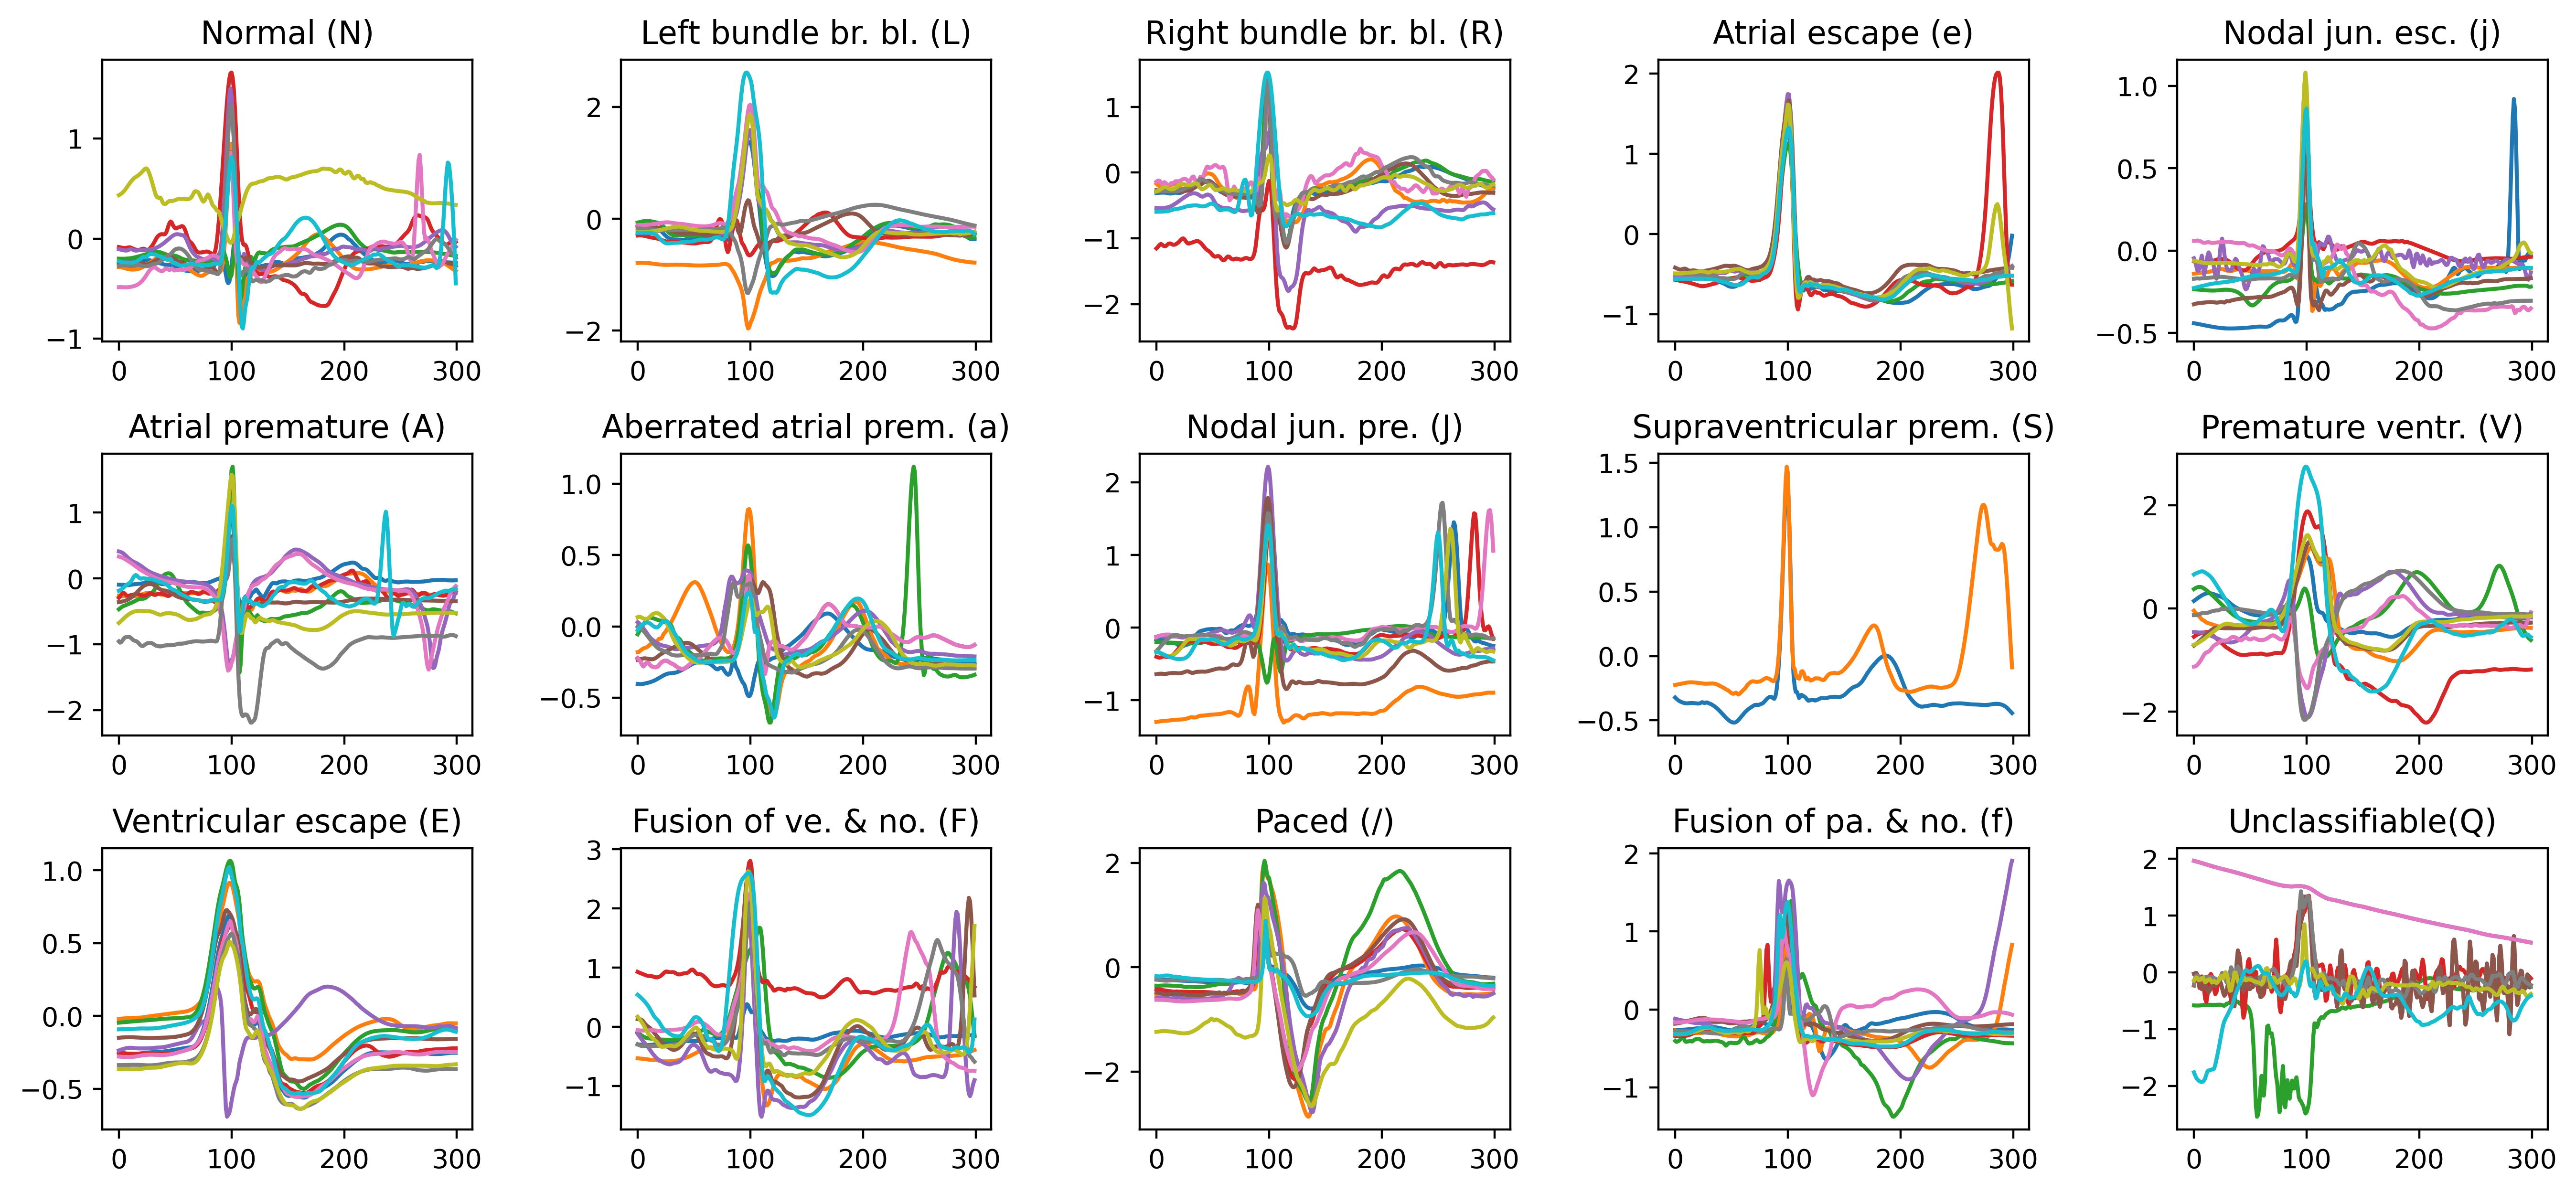

In [53]:
# Plotting 15 different types of heartbeat
fig = plt.figure(figsize=(16,7), dpi=400)
fig.tight_layout(pad=15.0)
for i in range(15):
  plt.subplot(3,5,i+1)
  plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)
  Plot_Random_Beat(type=i, num=10)
#figure_path = '/content/gdrive/MyDrive/ECG Arrhythmia trying/Heartbeat_Figures/'
#fig.savefig(figure_path+ 'all_heartbeats.png')

# **Part D: Train-Test Splitting and Class Balancing**

## **D1: Data loading**
Data is already loaded, **this step can be skipped.** However, here the whole dataset is saved in a train_ds variable.

### **a. Load whole data**

In [54]:
# Load the dataset and preprocess it
def loadData():
    numberSet = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                 '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
                 '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
                 '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
                 '222', '223', '228', '230', '231', '232', '233', '234']  # 48 readings
    dataSet = []
    lableSet = []
    for n in numberSet:
        # getDataSet(n, dataSet, lableSet)
        dataSet, lableSet = getDataSet(n, dataSet, lableSet)

    # Turn numpy array, scramble the order
    dataSet = np.array(dataSet).reshape(-1, 300)
    lableSet = np.array(lableSet).reshape(-1, 1)
    train_ds = np.hstack((dataSet, lableSet))
    np.random.shuffle(train_ds)
    return train_ds

In [55]:
# Load the whole dataset (109305,301). Each row indicate an ECG beat time series data upto 300
# and 301 column is its label among 15 difference level
train_ds = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

In [58]:
Y = train_ds[:, 300]

In [59]:
# Here 15 class of ECG data are saved
Y_list = list(Y)
Counter(Y_list)

Counter({np.float64(2.0): 7244,
         np.float64(0.0): 74920,
         np.float64(13.0): 982,
         np.float64(12.0): 7012,
         np.float64(9.0): 7123,
         np.float64(1.0): 8063,
         np.float64(5.0): 2540,
         np.float64(11.0): 802,
         np.float64(6.0): 150,
         np.float64(10.0): 106,
         np.float64(4.0): 229,
         np.float64(3.0): 16,
         np.float64(7.0): 83,
         np.float64(14.0): 33,
         np.float64(8.0): 2})

In [60]:
from collections import Counter
import numpy as np

# Convert Y to list
Y_list = list(Y)

# Count occurrences
count_dict = Counter(Y_list)

# Sort the counter by key (class label)
sorted_counts = dict(sorted(count_dict.items(), key=lambda x: x[0]))

# Display in order
for k, v in sorted_counts.items():
    print(f"Class {int(k)}: {v}")

Class 0: 74920
Class 1: 8063
Class 2: 7244
Class 3: 16
Class 4: 229
Class 5: 2540
Class 6: 150
Class 7: 83
Class 8: 2
Class 9: 7123
Class 10: 106
Class 11: 802
Class 12: 7012
Class 13: 982
Class 14: 33


### **b. 15 types to 5 level conversion**

In [61]:
# 15 level to 5 level conversion
Y_5class = np.copy(Y)

for i in range(Y.shape[0]):
  # print(i)
  if 0 <= Y[i] <= 4:
    Y_5class[i] = 0
  if 5 <= Y[i] <= 8:
    Y_5class[i] = 1
  if 9 <= Y[i] <= 10:
    Y_5class[i] = 2
  if Y[i] == 11:
    Y_5class[i] = 3
  if 12 <= Y[i] <= 14:
    Y_5class[i] = 4
print('changing done')

changing done


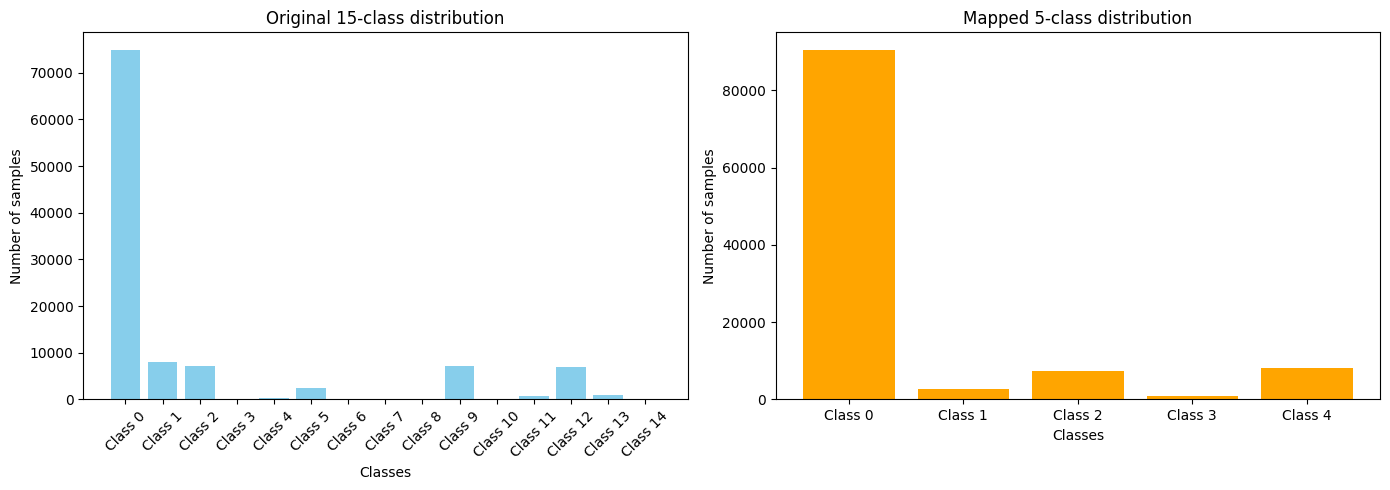

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Assuming Y is the original 15-class labels
# And Y_5class is the mapped 5-class labels

# Count original 15-class
count_15 = Counter(Y)
labels_15 = [f'Class {i}' for i in range(15)]
values_15 = [count_15[i] for i in range(15)]

# Count new 5-class
count_5 = Counter(Y_5class)
labels_5 = [f'Class {i}' for i in range(5)]
values_5 = [count_5[i] for i in range(5)]

# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Original 15-class distribution
ax[0].bar(labels_15, values_15, color='skyblue')
ax[0].set_title('Original 15-class distribution')
ax[0].set_ylabel('Number of samples')
ax[0].set_xlabel('Classes')
ax[0].tick_params(axis='x', rotation=45)

# Mapped 5-class distribution
ax[1].bar(labels_5, values_5, color='orange')
ax[1].set_title('Mapped 5-class distribution')
ax[1].set_ylabel('Number of samples')
ax[1].set_xlabel('Classes')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

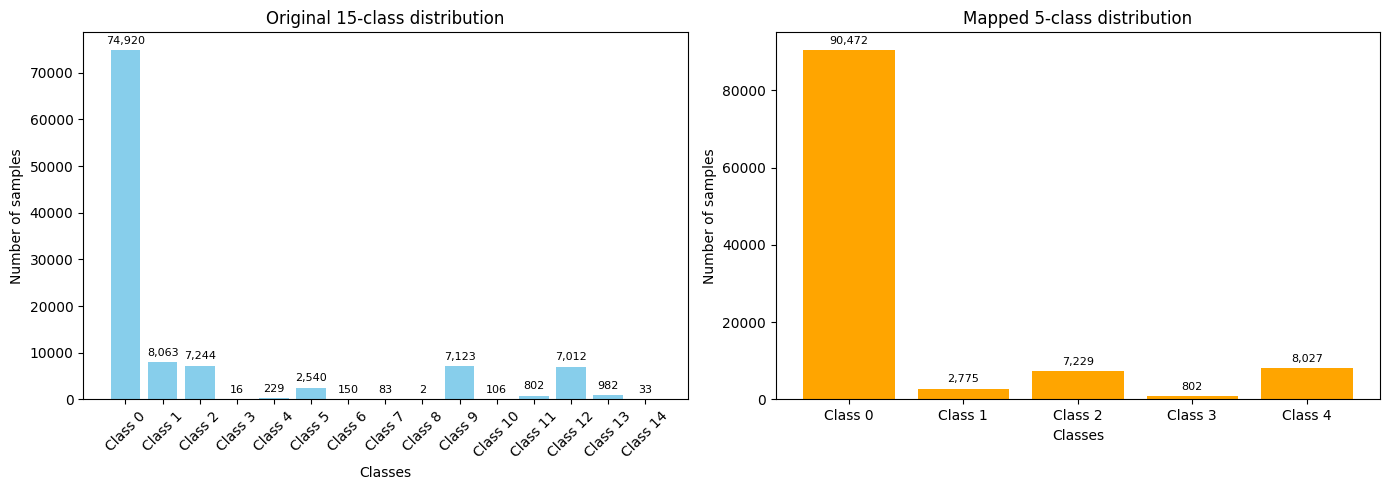

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Assuming Y is the original 15-class labels
# And Y_5class is the mapped 5-class labels

# Count original 15-class
count_15 = Counter(Y)
labels_15 = [f'Class {i}' for i in range(15)]
values_15 = [count_15[i] for i in range(15)]

# Count new 5-class
count_5 = Counter(Y_5class)
labels_5 = [f'Class {i}' for i in range(5)]
values_5 = [count_5[i] for i in range(5)]

# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Original 15-class distribution
bars1 = ax[0].bar(labels_15, values_15, color='skyblue')
ax[0].set_title('Original 15-class distribution')
ax[0].set_ylabel('Number of samples')
ax[0].set_xlabel('Classes')
ax[0].tick_params(axis='x', rotation=45)

# Annotate counts on top of bars
for bar in bars1:
    height = bar.get_height()
    ax[0].annotate(f'{height:,}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0,3),  # 3 points vertical offset
                   textcoords='offset points',
                   ha='center', va='bottom',
                   fontsize=8)

# Mapped 5-class distribution
bars2 = ax[1].bar(labels_5, values_5, color='orange')
ax[1].set_title('Mapped 5-class distribution')
ax[1].set_ylabel('Number of samples')
ax[1].set_xlabel('Classes')
ax[1].tick_params(axis='x', rotation=0)

# Annotate counts on top of bars
for bar in bars2:
    height = bar.get_height()
    ax[1].annotate(f'{height:,}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0,3),
                   textcoords='offset points',
                   ha='center', va='bottom',
                   fontsize=8)

plt.tight_layout()
plt.show()

In [64]:
Y_5class_list = list(Y_5class)
Counter(Y_5class_list)

Counter({np.float64(0.0): 90472,
         np.float64(4.0): 8027,
         np.float64(2.0): 7229,
         np.float64(1.0): 2775,
         np.float64(3.0): 802})

In [66]:
ecg_dataset = np.copy(train_ds)

In [65]:
# label encode the target variable # just convert numpy.float64 to numpy.int64
from sklearn.preprocessing import LabelEncoder
Y_5class = LabelEncoder().fit_transform(Y_5class)

In [67]:
ecg_data = ecg_dataset[:, :300]
ecg_lable = Y_5class.reshape(-1, 1) # otherwise np.hstack will not work

In [68]:
# Complete ECG dataset with 5 type of Arrhythmia
ecg_dataset_5 = np.hstack((ecg_data, ecg_lable))

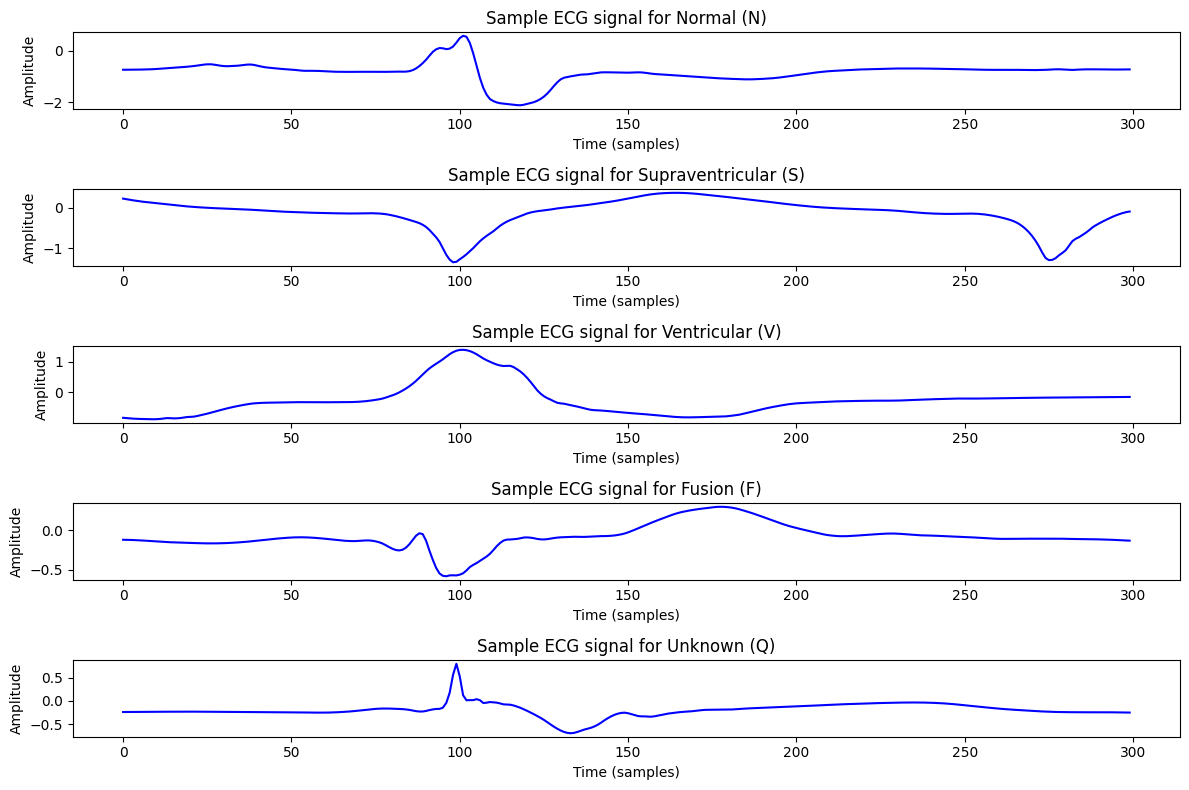

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose ecg_data is shape (N_samples, signal_length)
# and ecg_label is shape (N_samples,) with values 0-4 (5 arrhythmia classes)

classes = ["Normal (N)",
           "Supraventricular (S)",
           "Ventricular (V)",
           "Fusion (F)",
           "Unknown (Q)"]

plt.figure(figsize=(12, 8))

for i, cls in enumerate(np.unique(ecg_lable)):
    idx = np.where(ecg_lable == cls)[0][0]   # pick one example
    plt.subplot(5, 1, i+1)
    plt.plot(ecg_data[idx], color="blue")
    plt.title(f"Sample ECG signal for {classes[cls]}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

### **c. Per class data status checking (Full data)**

In [70]:
# Convert ndarray to dataframe
df_ecg = pd.DataFrame(ecg_dataset_5)
class_data = df_ecg[300].value_counts()
class_data

,count
300,
0.0,90472
4.0,8027
2.0,7229
1.0,2775
3.0,802


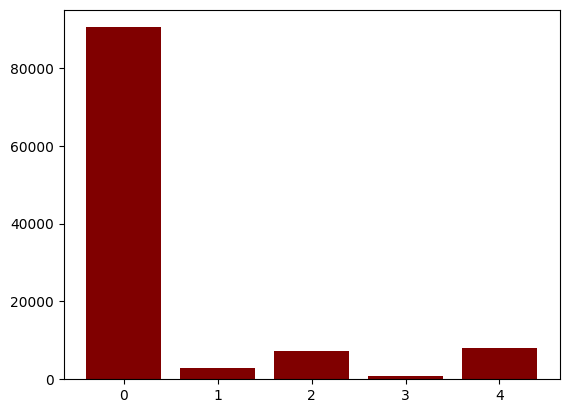

In [71]:
# per class data status plotting,
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

<Axes: xlabel='300'>

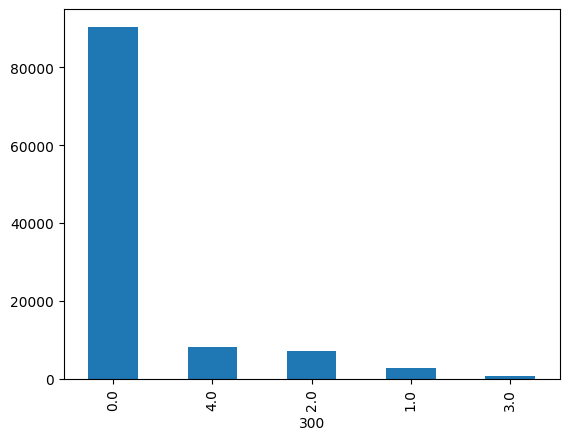

In [72]:
# shortcut for per class data status plotting,
# Order is not maintained by class. Higher to lower
df_ecg[300].value_counts().plot(kind='bar')

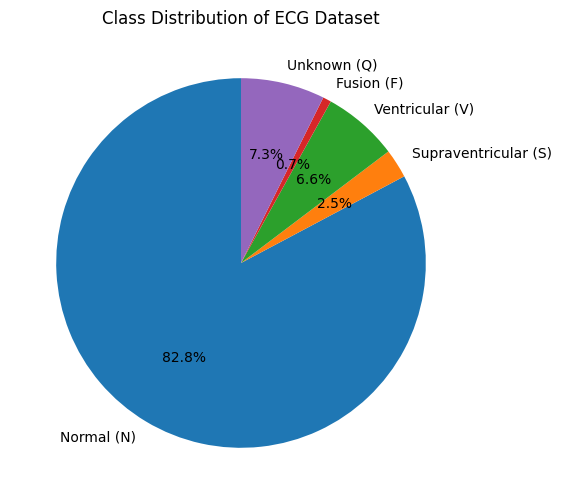

In [73]:
import matplotlib.pyplot as plt
import numpy as np

classes = ["Normal (N)", "Supraventricular (S)", "Ventricular (V)", "Fusion (F)", "Unknown (Q)"]

unique, counts = np.unique(ecg_lable, return_counts=True)

plt.figure(figsize=(6,6))
plt.pie(counts, labels=[classes[i] for i in unique], autopct='%1.1f%%', startangle=90)
plt.title("Class Distribution of ECG Dataset")
plt.show()

## **D2: Train-Test Spliting**
**Note: Class Balance should be done on Training Data Only. Not Testing Data.**

In [74]:
# train test splitting
from sklearn.model_selection import train_test_split
ecg_data = ecg_dataset_5[:, :300]
ecg_label = ecg_dataset_5[:, 300]
x_train, x_test, y_train, y_test = train_test_split(ecg_data, ecg_label,
                                   random_state=104,
                                   test_size=0.20,
                                   shuffle=True)

In [75]:
from sklearn.model_selection import train_test_split

# Suppose you already have:
# x_train, x_test, y_train, y_test = train_test_split(ecg_data, ecg_label, ...)

# Now split your training data again:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,  # 20% of training for validation set
    random_state=104,
    shuffle=True
)

In [76]:
# reshaping for using hstack function
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
train_data = np.hstack((x_train, y_train))
test_data = np.hstack((x_test, y_test))

In [77]:
#  converting dataframe
train_data = pd.DataFrame(train_data)
test_data = pd.DataFrame(test_data)

In [78]:
# saving the test data (in imbalanced condition)
file_name = project_path + 'test_data.pkl'
test_data.to_pickle(file_name)

**Training dataset status checking:** balanced / imbalanced

300
0.0    57893
4.0     5130
2.0     4603
1.0     1804
3.0      525
Name: count, dtype: int64


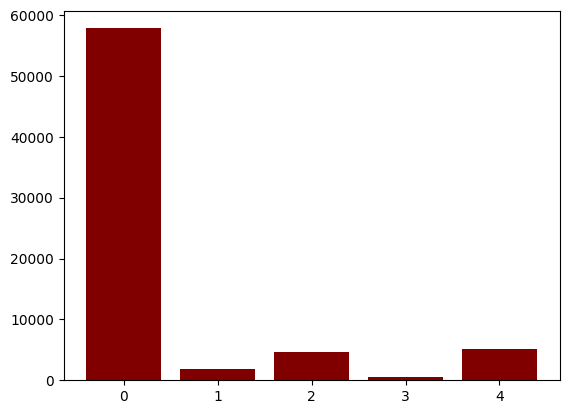

In [79]:
# Imblanced training data graph ploting
class_data = train_data[300].value_counts()
print(class_data)
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

Train Set Class Distribution:
0.0    57893
1.0     1804
2.0     4603
3.0      525
4.0     5130
Name: count, dtype: int64

Validation Set Class Distribution:
0.0    14503
1.0      419
2.0     1170
3.0      106
4.0     1291
Name: count, dtype: int64

Test Set Class Distribution:
0.0    18076
1.0      552
2.0     1456
3.0      171
4.0     1606
Name: count, dtype: int64


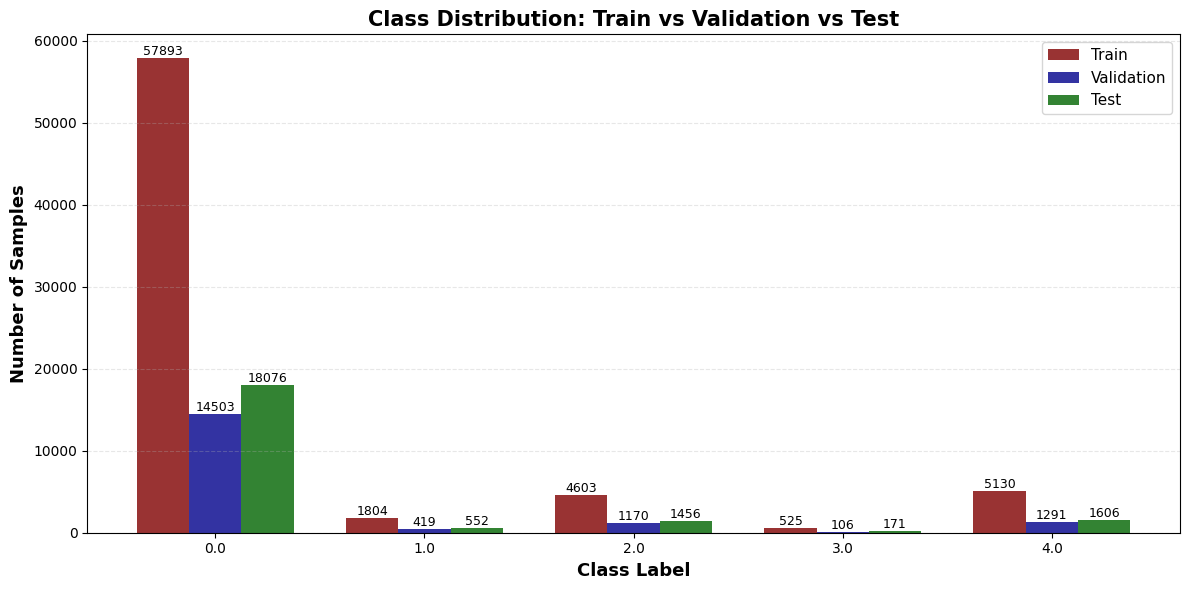

In [80]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming you have already split your data
# ecg_data = ecg_dataset_5[:, :300]
# ecg_label = ecg_dataset_5[:, 300]
# x_train, x_test, y_train, y_test = train_test_split(...)
# x_train, x_val, y_train, y_val = train_test_split(...)

# Extract labels from your splits
# If your labels are stored in y_train, y_val, y_test

# Method 1: If you have the original DataFrame-like structure
# Create DataFrames or Series from your label arrays
train_labels = pd.Series(y_train.flatten() if len(y_train.shape) > 1 else y_train)
val_labels = pd.Series(y_val.flatten() if len(y_val.shape) > 1 else y_val)
test_labels = pd.Series(y_test.flatten() if len(y_test.shape) > 1 else y_test)

# Count class occurrences
train_class_data = train_labels.value_counts().sort_index()
val_class_data = val_labels.value_counts().sort_index()
test_class_data = test_labels.value_counts().sort_index()

# Print statistics
print("Train Set Class Distribution:")
print(train_class_data)
print("\nValidation Set Class Distribution:")
print(val_class_data)
print("\nTest Set Class Distribution:")
print(test_class_data)

# Create grouped bar chart
classes = train_class_data.index
x_pos = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x_pos - width, train_class_data.values, width, label='Train', color='maroon', alpha=0.8)
plt.bar(x_pos, val_class_data.values, width, label='Validation', color='darkblue', alpha=0.8)
plt.bar(x_pos + width, test_class_data.values, width, label='Test', color='darkgreen', alpha=0.8)

plt.xlabel('Class Label', fontsize=13, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=13, fontweight='bold')
plt.title('Class Distribution: Train vs Validation vs Test', fontsize=15, fontweight='bold')
plt.xticks(x_pos, classes)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, pos in enumerate(x_pos):
    plt.text(pos - width, train_class_data.values[i], str(train_class_data.values[i]),
             ha='center', va='bottom', fontsize=9)
    plt.text(pos, val_class_data.values[i], str(val_class_data.values[i]),
             ha='center', va='bottom', fontsize=9)
    plt.text(pos + width, test_class_data.values[i], str(test_class_data.values[i]),
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## **D3: Class balancing by undersampling and SMOTE**
**SMOTE** stands for '**Synthetic Minority Oversampling Technique**'.
Plan for train data
1. Class 1: Randomly selected 50000 data
2. Class 1, 2, 3, 4: Use SMOTE to oversample upto 50000 data

=== DEBUGGING INFO ===
y_train shape: (69955, 1)
y_train type: <class 'numpy.ndarray'>
First 5 samples of y_train:
[[2.]
 [0.]
 [0.]
 [0.]
 [4.]]

✓ Detected 2D integer labels

y_train_original shape: (69955,)
Unique classes in y_train_original: [0 1 2 3 4]
Number of unique classes: 5
Class distribution:
Counter({np.int64(0): 57893, np.int64(4): 5130, np.int64(2): 4603, np.int64(1): 1804, np.int64(3): 525})

✓ Found 5 classes - proceeding with SMOTE

=== ORIGINAL CLASS DISTRIBUTION ===
Counter({np.int64(0): 57893, np.int64(4): 5130, np.int64(2): 4603, np.int64(1): 1804, np.int64(3): 525})

=== BALANCED CLASS DISTRIBUTION (AFTER SMOTE) ===
Counter({np.int64(2): 57893, np.int64(0): 57893, np.int64(4): 57893, np.int64(3): 57893, np.int64(1): 57893})


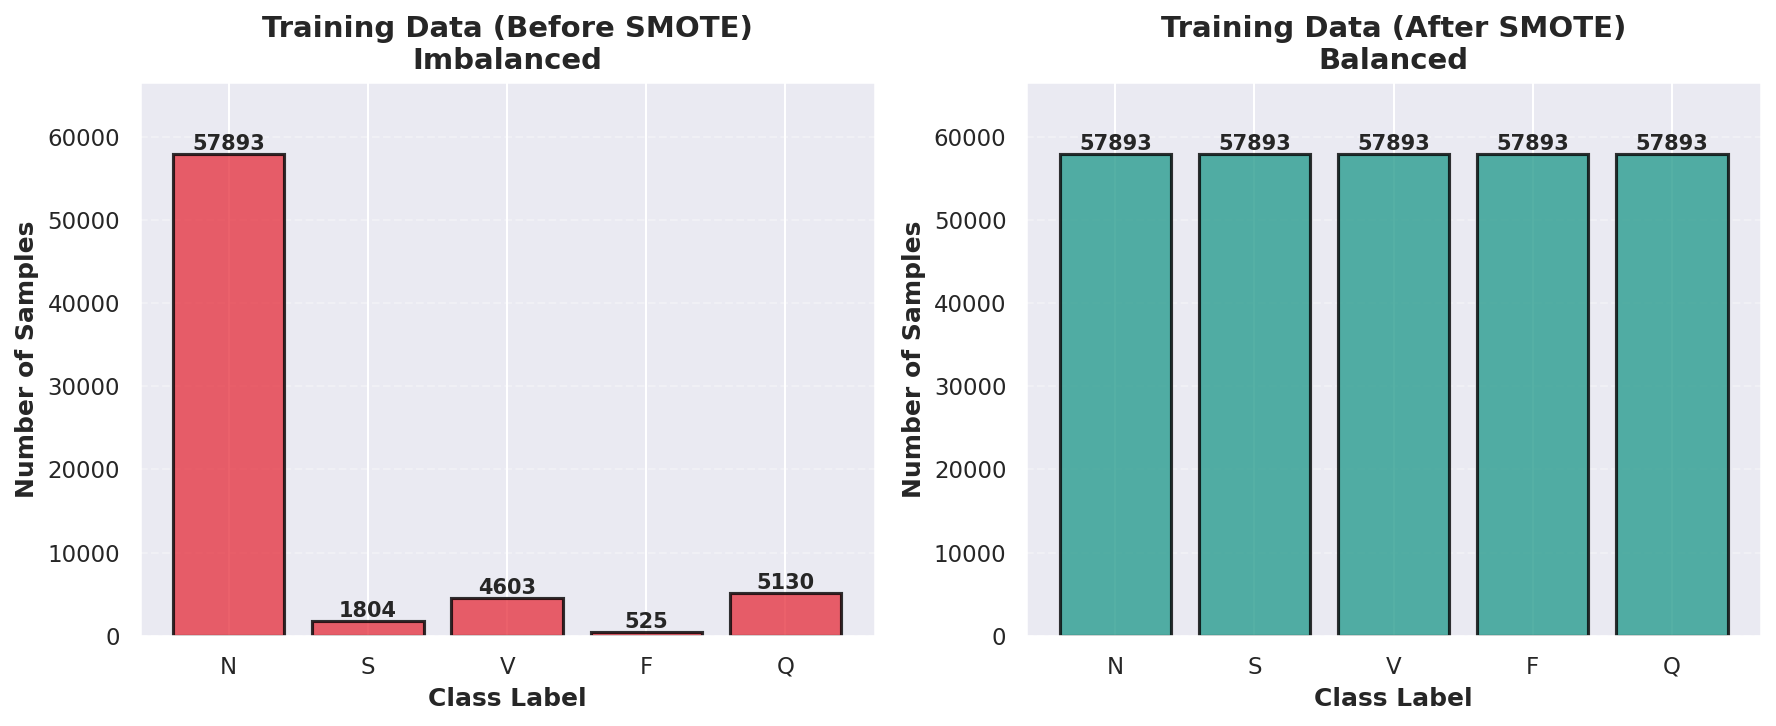


=== CREATING BALANCED DATAFRAME ===
train_data_r shape: (289465, 301)
train_data_r columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 2

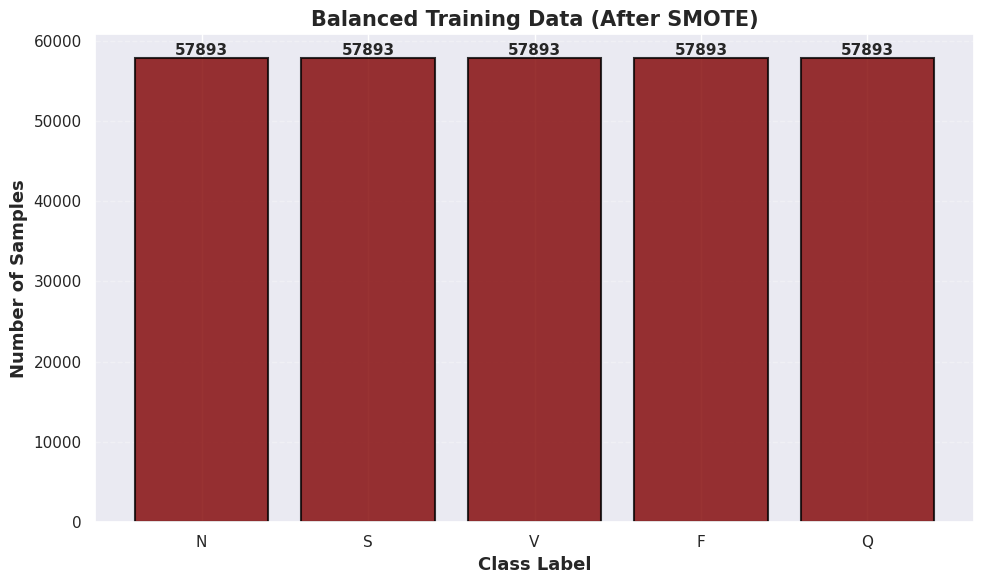


=== SAVING BALANCED DATA ===
✓ Saved balanced data as pickle: ./arrhythmia_project/train_data_SMOTE.pkl
  File size: 664.74 MB
✓ Saved balanced data as NPZ: ./arrhythmia_project/train_data_SMOTE.npz
  File size: 631.03 MB

               SMOTE BALANCING SUMMARY

Before SMOTE:
  Class N: 57893 samples
  Class S: 1804 samples
  Class V: 4603 samples
  Class F: 525 samples
  Class Q: 5130 samples

After SMOTE:
  Class N: 57893 samples
  Class S: 57893 samples
  Class V: 57893 samples
  Class F: 57893 samples
  Class Q: 57893 samples

Total Samples:
  Before: 69955
  After: 289465
  Increase: 219510 samples

Saved Files:
  1. ./arrhythmia_project/train_data_SMOTE.pkl
  2. ./arrhythmia_project/train_data_SMOTE.npz

✓ PROCESS COMPLETE!


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter
import os

# ==================== DEBUG: CHECK YOUR DATA ====================
print("=== DEBUGGING INFO ===")
print(f"y_train shape: {y_train.shape}")
print(f"y_train type: {type(y_train)}")
print(f"First 5 samples of y_train:\n{y_train[:5]}")

# ==================== EXTRACT LABELS CORRECTLY ====================
# Method 1: If one-hot encoded (shape: (samples, 5))
if len(y_train.shape) == 2 and y_train.shape[1] > 1:
    print("\n✓ Detected one-hot encoded labels")
    y_train_original = np.argmax(y_train, axis=1)
# Method 2: If already integers but in 2D (shape: (samples, 1))
elif len(y_train.shape) == 2 and y_train.shape[1] == 1:
    print("\n✓ Detected 2D integer labels")
    y_train_original = y_train.flatten().astype(int)
# Method 3: If already 1D integers
else:
    print("\n✓ Detected 1D integer labels")
    y_train_original = y_train.astype(int)

# ==================== VERIFY EXTRACTION ====================
print(f"\ny_train_original shape: {y_train_original.shape}")
print(f"Unique classes in y_train_original: {np.unique(y_train_original)}")
print(f"Number of unique classes: {len(np.unique(y_train_original))}")
print(f"Class distribution:\n{Counter(y_train_original)}")

# Check if we have multiple classes
if len(np.unique(y_train_original)) <= 1:
    print("\n❌ ERROR: Only 1 class found! Check your data split.")
    print("This usually means:")
    print("1. Labels were not extracted correctly")
    print("2. Data split was done incorrectly")
    print("3. Need to re-run the data preparation steps")
else:
    print(f"\n✓ Found {len(np.unique(y_train_original))} classes - proceeding with SMOTE")

    # ==================== RESHAPE FOR SMOTE ====================
    x_train_reshaped = x_train.reshape(x_train.shape[0], -1)

    # Count original distribution
    original_counts = Counter(y_train_original)
    print("\n=== ORIGINAL CLASS DISTRIBUTION ===")
    print(original_counts)

    # ==================== APPLY SMOTE ====================
    smote = SMOTE(random_state=104)
    x_train_balanced, y_train_balanced = smote.fit_resample(x_train_reshaped, y_train_original)

    # Count balanced distribution
    balanced_counts = Counter(y_train_balanced)
    print("\n=== BALANCED CLASS DISTRIBUTION (AFTER SMOTE) ===")
    print(balanced_counts)

    # ==================== PREPARE FOR PLOTTING ====================
    classes = sorted(original_counts.keys())
    class_labels = ['N', 'S', 'V', 'F', 'Q']

    original_values = [original_counts[c] for c in classes]
    balanced_values = [balanced_counts[c] for c in classes]

    # ==================== PLOT ====================
    sns.set()
    sns.set_palette("hls", 8)

    fig = plt.figure(figsize=(12, 5), dpi=150)

    # Before SMOTE
    plt.subplot(121)
    bars1 = plt.bar(class_labels, original_values, color='#E63946', alpha=0.8, edgecolor='black', linewidth=1.5)
    plt.ylim(0, max(max(original_values), max(balanced_values)) * 1.15)
    plt.title('Training Data (Before SMOTE)\nImbalanced', fontsize=14, fontweight='bold')
    plt.xlabel('Class Label', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars1, original_values)):
        plt.text(bar.get_x() + bar.get_width()/2., val,
                 f'{int(val)}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # After SMOTE
    plt.subplot(122)
    bars2 = plt.bar(class_labels, balanced_values, color='#2A9D8F', alpha=0.8, edgecolor='black', linewidth=1.5)
    plt.ylim(0, max(max(original_values), max(balanced_values)) * 1.15)
    plt.title('Training Data (After SMOTE)\nBalanced', fontsize=14, fontweight='bold')
    plt.xlabel('Class Label', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars2, balanced_values)):
        plt.text(bar.get_x() + bar.get_width()/2., val,
                 f'{int(val)}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ==================== CREATE DATAFRAME WITH BALANCED DATA ====================
    print("\n=== CREATING BALANCED DATAFRAME ===")

    # Combine features and labels into DataFrame
    train_data_resampled = np.column_stack([x_train_balanced, y_train_balanced])
    train_data_r = pd.DataFrame(train_data_resampled)

    print(f"train_data_r shape: {train_data_r.shape}")
    print(f"train_data_r columns: {train_data_r.columns.tolist()}")

    # ==================== PLOT BALANCED DATA (SINGLE BAR CHART) ====================
    print("\n=== PLOTTING BALANCED DATA ===")

    # Get class distribution from column 300 (last column = labels)
    class_data = train_data_r[300].value_counts().sort_index()
    print("\nBalanced class distribution:")
    print(class_data)

    # Create single bar plot
    plt.figure(figsize=(10, 6))
    plt.bar(class_data.index, class_data.values, color='maroon', alpha=0.8, edgecolor='black', linewidth=1.5)
    plt.xlabel('Class Label', fontsize=13, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=13, fontweight='bold')
    plt.title('Balanced Training Data (After SMOTE)', fontsize=15, fontweight='bold')
    plt.xticks(class_data.index, ['N', 'S', 'V', 'F', 'Q'])
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels on bars
    for idx, val in zip(class_data.index, class_data.values):
        plt.text(idx, val, f'{int(val)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ==================== SAVE BALANCED TRAINING DATA ====================
    print("\n=== SAVING BALANCED DATA ===")

    # Define project path
    project_path = './arrhythmia_project/'
    os.makedirs(project_path, exist_ok=True)

    # Save as pickle
    file_name = project_path + 'train_data_SMOTE.pkl'
    train_data_r.to_pickle(file_name)

    print(f"✓ Saved balanced data as pickle: {file_name}")
    print(f"  File size: {os.path.getsize(file_name) / (1024*1024):.2f} MB")

    # ==================== ALSO SAVE AS NPZ (RECOMMENDED) ====================
    # Reshape back to 3D for model use
    x_train_balanced_3d = x_train_balanced.reshape(-1, 300, 1)

    # Save in NPZ format (better for array data)
    file_name_npz = project_path + 'train_data_SMOTE.npz'
    np.savez_compressed(file_name_npz,
                       x_train=x_train_balanced_3d,
                       y_train=y_train_balanced)

    print(f"✓ Saved balanced data as NPZ: {file_name_npz}")
    print(f"  File size: {os.path.getsize(file_name_npz) / (1024*1024):.2f} MB")

    # ==================== SUMMARY ====================
    print("\n" + "="*60)
    print(" "*15 + "SMOTE BALANCING SUMMARY")
    print("="*60)
    print(f"\nBefore SMOTE:")
    for i, cls in enumerate(class_labels):
        if i < len(original_values):
            print(f"  Class {cls}: {original_values[i]} samples")

    print(f"\nAfter SMOTE:")
    for i, cls in enumerate(class_labels):
        if i < len(balanced_values):
            print(f"  Class {cls}: {balanced_values[i]} samples")

    print(f"\nTotal Samples:")
    print(f"  Before: {sum(original_values)}")
    print(f"  After: {sum(balanced_values)}")
    print(f"  Increase: {sum(balanced_values) - sum(original_values)} samples")

    print(f"\nSaved Files:")
    print(f"  1. {file_name}")
    print(f"  2. {file_name_npz}")
    print("="*60)

print("\n✓ PROCESS COMPLETE!")


In [82]:
import pandas as pd
import numpy as np

project_path = './arrhythmia_project/'

# Method 1: Load from pickle
train_data_r = pd.read_pickle(project_path + 'train_data_SMOTE.pkl')
print(f"Loaded from pickle: {train_data_r.shape}")

# Extract features and labels
x_train_balanced = train_data_r.iloc[:, :-1].values
y_train_balanced = train_data_r.iloc[:, -1].values

# Method 2: Load from NPZ (recommended)
data = np.load(project_path + 'train_data_SMOTE.npz')
x_train_3d = data['x_train']
y_train = data['y_train']

print(f"Loaded from NPZ:")
print(f"  x_train shape: {x_train_3d.shape}")
print(f"  y_train shape: {y_train.shape}")

Loaded from pickle: (289465, 301)
Loaded from NPZ:
  x_train shape: (289465, 300, 1)
  y_train shape: (289465,)


# **Part E: Model Building and Training**
A **CNN-LSTM and attention** based hybrid model is formulated.

## **E1: Attention Mechanism**
**Convolutional Block Attention Module** ([CBAM](https://arxiv.org/abs/1807.06521)) consists two parts (i) **channel attention**, (ii) spatial attention. ECG is an 1D signal and 1-lead ECG is used in the modle.Therefore, only channel attention is only used.

In [85]:
# UDF for Channel Attention Mechanism

import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, GlobalAveragePooling1D, GlobalMaxPooling1D, Add, Activation, Multiply, Reshape

class ChannelAttention(Layer):
    def __init__(self, filters, ratio=8):
        super(ChannelAttention, self).__init__()
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        # Shared MLP layers
        self.shared_dense_one = Dense(self.filters // self.ratio,
                                      activation='relu',
                                      kernel_initializer='he_normal',
                                      use_bias=True,
                                      bias_initializer='zeros')
        self.shared_dense_two = Dense(self.filters,
                                      kernel_initializer='he_normal',
                                      use_bias=True,
                                      bias_initializer='zeros')

    def call(self, inputs):
        # Average pooling across spatial (temporal) dimension
        avg_pool = GlobalAveragePooling1D()(inputs)
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)

        # Max pooling across spatial (temporal) dimension
        max_pool = GlobalMaxPooling1D()(inputs)
        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)

        # Combine, apply sigmoid activation
        # Add shape expansion for broadcasting
        attention = Add()([avg_pool, max_pool])
        attention = Activation('sigmoid')(attention)
        attention = Reshape((1, self.filters))(attention)

        # Multiply with input (broadcasts across time/sequence dimension)
        return Multiply()([inputs, attention])

        return tf.keras.layers.Multiply()([inputs, attention])

In [86]:
# udf for spatial attention mechanism
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv1D, Concatenate, Lambda, Multiply

class SpatialAttention1D(Layer):
    def __init__(self, kernel_size=7):
        super(SpatialAttention1D, self).__init__()
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv1d = Conv1D(filters=1,
                             kernel_size=self.kernel_size,
                             strides=1,
                             padding='same',
                             activation='sigmoid',
                             kernel_initializer='he_normal',
                             use_bias=False)

    def call(self, inputs):
        # Pool across channels (-1 axis)
        avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(inputs)
        max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(inputs)
        concat = Concatenate(axis=-1)([avg_pool, max_pool])
        attention = self.conv1d(concat)
        return Multiply()([inputs, attention])


## **E2: CNN-LSTM and attention model architecture**

### **a. Model building**

In [87]:
import tensorflow as tf

def buildModel():
    newModel = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(300, 1)),

        # Increased filters and kernel size for deeper feature extraction
        tf.keras.layers.Conv1D(filters=32, kernel_size=25, strides=1, padding='same', activation='relu'),
        ChannelAttention(32, 4),    # Efficient ratio for attention
        SpatialAttention(11),       # Larger kernel for robust segment-wise feature mapping

        # First pooling layer
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),

        # Second convolution layer with more filters and larger kernel
        tf.keras.layers.Conv1D(filters=48, kernel_size=27, strides=1, padding='same', activation='relu'),
        ChannelAttention(48, 4),
        SpatialAttention(11),

        # Second pooling layer
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),

        # Third convolution layer with further increase in filters
        tf.keras.layers.Conv1D(filters=96, kernel_size=29, strides=1, padding='same', activation='relu'),
        ChannelAttention(96, 4),
        SpatialAttention(11),

        # Third pooling layer
        tf.keras.layers.AvgPool1D(pool_size=3, strides=2, padding='same'),

        # Fourth convolution layer, high filter count for deep features
        tf.keras.layers.Conv1D(filters=160, kernel_size=31, strides=1, padding='same', activation='relu'),
        ChannelAttention(160, 4),
        SpatialAttention(11),

        # LSTM layers for temporal dynamics, lighter dropout for better retention
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(rate=0.15),
        tf.keras.layers.LSTM(32, return_sequences=True),

        # Dense and flatten for classification
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(rate=0.15),
        tf.keras.layers.Dense(5, activation='softmax')
    ])
    return newModel

### **b. Hyperparameter Tuning**
Many architectures of model is found by changing hyperparameters.
* Model: with or without channel or spatial attention.
* CNN Filters: Number of filters in each Conv layer is changing like 4, 16, 32, 64, 128 etc.
* LSTM Units: Number of units of two LSTM layer is varing like 32, 64, 128 etc.

In [89]:
import tensorflow as tf

def buildModel():
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(300, 1)),

        # First convolutional block
        tf.keras.layers.Conv1D(filters=32, kernel_size=21, strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),

        # Second convolutional block
        tf.keras.layers.Conv1D(filters=64, kernel_size=23, strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),

        # Third convolutional block
        tf.keras.layers.Conv1D(filters=128, kernel_size=25, strides=1, padding='same', activation='relu'),
        tf.keras.layers.AvgPool1D(pool_size=3, strides=2, padding='same'),

        # Fourth convolutional block
        tf.keras.layers.Conv1D(filters=160, kernel_size=27, strides=1, padding='same', activation='relu'),

        # LSTM layers for temporal dependencies
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(rate=0.15),
        tf.keras.layers.LSTM(32, return_sequences=True),

        # Flatten for dense layers
        tf.keras.layers.Flatten(),

        # Dense classification head
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(rate=0.15),
        tf.keras.layers.Dense(5, activation='softmax')
    ])
    return model


### **c. Model Training**

**Build, save and then Fit the Model.**
If we have already the saved model, then no need to build, save and fit again.

In [93]:
import os
from datetime import datetime

# Set your project path
project_path = "/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0"  # <-- change this to your actual base path, always ending with '/'

# Define the log directory with current date and time for uniqueness
logdir = os.path.join(project_path, "logs", datetime.now().strftime("%Y%m%d-%H%M%S"))

# Create the log directory if it doesn't exist
os.makedirs(logdir, exist_ok=True)

# Define your model path (use underscores or standard naming, avoid spaces)
model_path = os.path.join(project_path, "ecg_model_code_17_t5.h5")

In [95]:
# percentage of training data used for model validation
ratio = 0.2

In [ ]:
import os
from datetime import datetime
import tensorflow as tf

# Set your project and directory paths
project_path = "/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0"  # Update this for your system
logdir = os.path.join(project_path, "logs", datetime.now().strftime("%Y%m%d-%H%M%S"))
model_path = os.path.join(project_path, "ecg_model_code_17_t5.h5")
checkpoint_filepath = os.path.join(project_path, "code_17_t5_weights.weights.h5")
os.makedirs(logdir, exist_ok=True)

# Check if model file exists
if os.path.exists(model_path):
    print('Model already exists at filepath.')
    model = tf.keras.models.load_model(model_path)
else:
    print('Model not found, building and saving now.')
    model = buildModel()
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()

    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=1)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,               # File must end with .weights.h5
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
    callback_list = [tensorboard_callback, model_checkpoint_callback]

    # Make sure x_train, y_train, ratio are defined before this block
    history = model.fit(
        x_train, y_train,
        epochs=30,
        batch_size=128,
        validation_split=ratio,
        callbacks=callback_list
    )
    model.save(model_path)

Model not found, building and saving now.


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_30 (Conv1D)              │ (None, 300, 32)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_31 (Conv1D)              │ (None, 150, 64)        │        47,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 75, 128)        │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_7             │ (None, 38, 128)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 38, 160)        │       553,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 38, 64)         │        57,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 38, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       155,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,032,357 (3.94 MB)

 Trainable params: 1,032,357 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 470s 1s/step - accuracy: 0.8767 - loss: 0.4217 - val_accuracy: 0.9532 - val_loss: 0.1526
Epoch 2/30
189/438 ━━━━━━━━━━━━━━━━━━━━ 4:04 982ms/step - accuracy: 0.9669 - loss: 0.1243

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=30, batch_size=128, validation_split=0.2)


Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.9862 - loss: 0.0539 - val_accuracy: 0.9917 - val_loss: 0.0331
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.9877 - loss: 0.0416 - val_accuracy: 0.9920 - val_loss: 0.0329
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9881 - loss: 0.0421 - val_accuracy: 0.9913 - val_loss: 0.0355
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9882 - loss: 0.0396 - val_accuracy: 0.9856 - val_loss: 0.0533
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.9886 - loss: 0.0375 - val_accuracy: 0.9915 - val_loss: 0.0341
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.9885 - loss: 0.0384 - val_accuracy: 0.9911 - val_loss: 0.0387
Epoch 7/30
360/547 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9902 - loss: 0.0318

KeyboardInterrupt: 

### **d. Plotting Accuracy and Loss**
Training and Validation accuray and loss curve plotting.

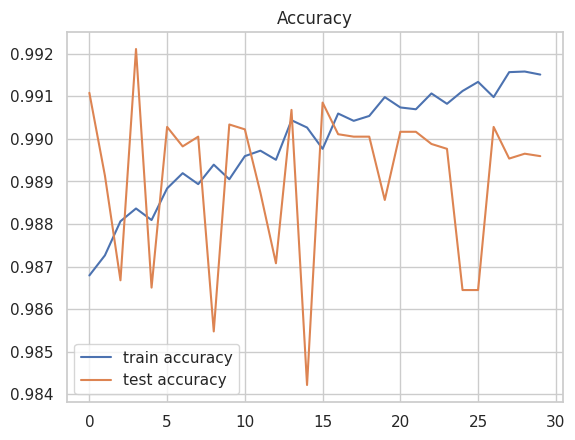

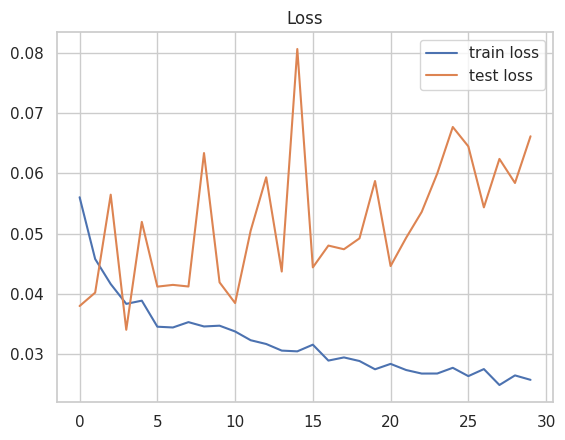

In [ ]:
# plot accuracy during training
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy') # label is actually 'validation accuracy'
plt.legend()
plt.show()

# plot loss during training
plt.title('Loss')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss') # label is actually 'validation accuracy'
plt.legend()
plt.show()

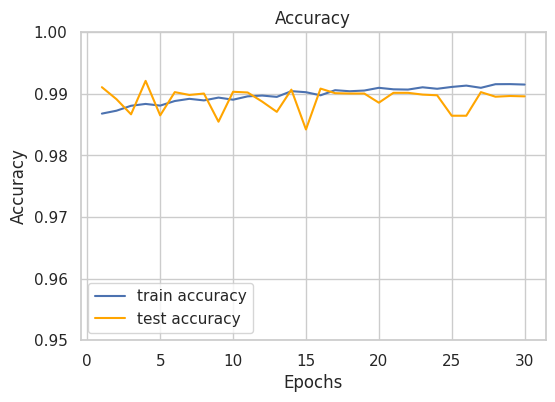

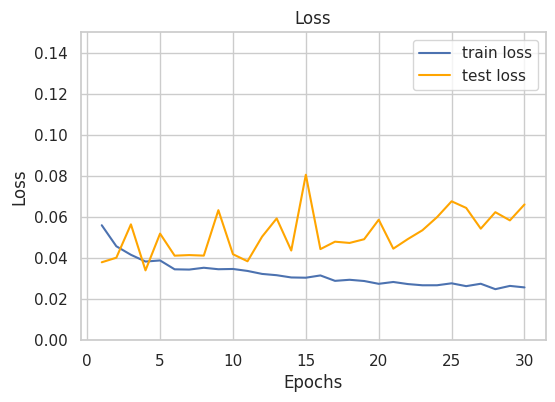

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have history from model.fit()
epochs = range(1, len(history.history['accuracy']) + 1)

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(epochs, history.history['accuracy'], 'b-', label='train accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'orange', label='test accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.95, 1)  # y-axis from 0.95 to 1
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(epochs, history.history['loss'], 'b-', label='train loss')
plt.plot(epochs, history.history['val_loss'], 'orange', label='test loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0.00, 0.15)  # Optional: adjust based on your loss values
plt.legend()
plt.grid(True)
plt.show()

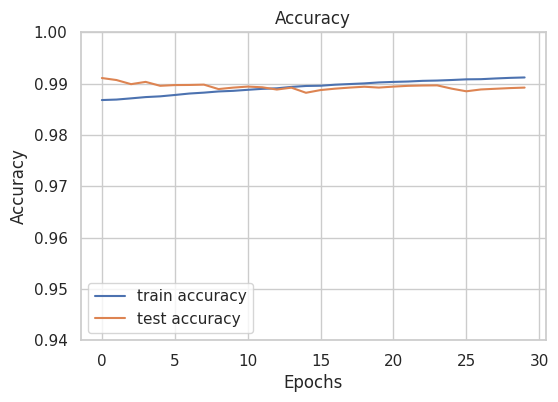

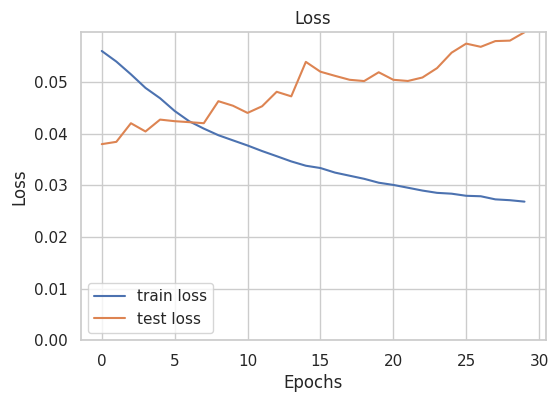

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(train_acc, label='train accuracy')
plt.plot(val_acc, label='test accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.94, 1.0)
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(6,4))
plt.plot(train_loss, label='train loss')
plt.plot(val_loss, label='test loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, max(max(train_loss), max(val_loss)))  # Adjust based on your data
plt.legend()
plt.grid(True)
plt.show()

# **Part F: Results**


## **F1: Classification Accuracy and Confusion Matrix**
The overall classification accuracy and confusion matrix generated by the follwoing code.

**Model Testing**
* a. Using **recently trained** and Saved Model after 30 Epochs.
* b. Using the **best model** saved by *'model checkpoint'* callback.

**a. Using Recently Trained Model**

In [ ]:
# Evaluate the model
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print('Training Accuracy: %.2f, Test Accuracy: %.2f' % (train_acc*100, test_acc*100))
print('Training Loss: %.2f, Test Loss: %.2f' % (train_loss*100, test_loss*100))

Training Accuracy: 99.51, Test Accuracy: 99.11
Training Loss: 2.18, Test Loss: 4.95


**b. Using the Best Model**
We saved many checkpoints of the model. Among these checkpoints we will consider the checkpoint which has the largest validation accuracy. Then copy its path and update the model weights.

**Confusion Matrix**

In [ ]:
# confusion matrix
def plotHeatMap(Y_test, Y_pred):
    con_mat = confusion_matrix(Y_test, Y_pred)
    # Normalized
    # con_mat_norm = con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis]
    # con_mat_norm = np.around(con_mat_norm, decimals=2)

    # Plotting
    plt.figure(figsize=(8, 8))
    seaborn.heatmap(con_mat, annot=True, square=True, fmt='.20g', cmap='Greens')
    plt.ylim(0, 5)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.show()

684/684 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


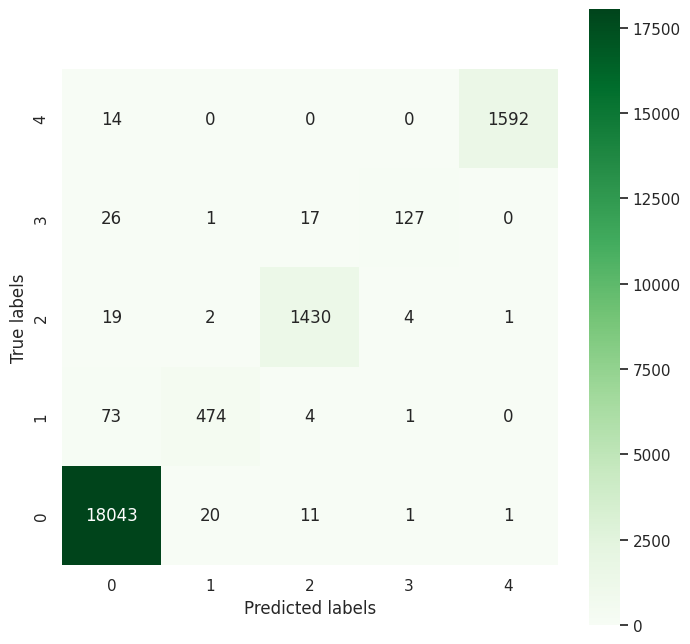

In [ ]:
# predict
Y_pred = np.argmax(model.predict(x_test), axis=-1)
# Y_pred = model.predict_classes(X_test)
# plot confusion matrix
plotHeatMap(y_test, Y_pred)

## **F2: Per Class Performance**
Calculating per class Sensitivity, Specificity, Accuracy and F1 score.

In [ ]:
# Per class accuracy printing function
def _report(TN, FP, FN, TP):
    TPR = TP/(TP+FN) if (TP+FN)!=0 else 0
    TNR = TN/(TN+FP) if (TN+FP)!=0 else 0
    PPV = TP/(TP+FP) if (TP+FP)!=0 else 0
    '''
    report = {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
              'TPR': TPR, 'Recall': TPR, 'Sensitivity': TPR,
              'TNR' : TNR, 'Specificity': TNR,
              'FPR': FP/(FP+TN) if (FP+TN)!=0 else 0,
              'FNR': FN/(FN+TP) if (FN+TP)!=0 else 0,
              'PPV': PPV, 'Precision': PPV,
              'F1 Score': 2*(PPV*TPR)/(PPV+TPR),
              'Per Class Accuracy': (TP+TN)/(TP+FP+FN+TN)
             }'''

    report = {'Sensitivity (%)': TPR*100,
              'Specificity (%)': TNR*100,
              'F1 Score (%)': 2*100*(PPV*TPR)/(PPV+TPR),
              'Per Class Accuracy (%)': (TP+TN)*100/(TP+FP+FN+TN)
             }
    return report

def multi_classification_report(y_test, y_pred, labels=None, encoded_labels=True, as_frame=False):
    """
    Args:
        y_test (ndarray)
        y_pred (ndarray)
        labels (list)
        encoded_labels (bool): Need to be False if labels are not one hot encoded
        as_fram (bool): If True, return type will be DataFrame

    Return:
        report (dict)
    """

    import numpy as np
    import pandas as pd
    from sklearn.metrics import multilabel_confusion_matrix

    conf_labels = None if encoded_labels else labels

    conf_mat = multilabel_confusion_matrix(y_test, y_pred, labels=conf_labels)
    report = dict()
    if labels == None:
        counter = np.arange(len(conf_mat))
    else:
        counter = labels

    for i, name in enumerate(counter):
        TN, FP, FN, TP = conf_mat[i].ravel()
        report[name] = _report(TN, FP, FN, TP)

    if as_frame:
        return pd.DataFrame(report)
    return report

**a. Recently Trained Model**

In [ ]:
# Per class performance
labels = ['N', 'S', 'V', 'F', 'Q']
Y_pred = np.argmax(model.predict(x_test), axis=-1)
multi_classification_report(y_test, Y_pred, labels=labels, encoded_labels=True, as_frame=True)

684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


,N,S,V,F,Q
Sensitivity (%),99.817437,85.869565,98.214286,74.269006,99.128269
Specificity (%),96.512550,99.892064,99.843176,99.972337,99.990126
F1 Score (%),99.544840,90.371783,98.012337,83.552632,99.500000
Per Class Accuracy (%),99.245231,99.537990,99.734687,99.771282,99.926810
